# ViFactCheck — Phần Tuyền đã rà soát

**Phạm vi TV1 Tuyền theo PDF CS221:**
- **3. Exploratory Data Analysis (EDA):** thống kê dataset, quyết định preprocessing, cơ sở lựa chọn mô hình và thiết kế pipeline.
- **4.1. Preprocessing cho TF-IDF + Logistic Regression:** làm sạch, chuẩn hóa từ vựng, tách từ, thử dấu câu/lowercase và loại stopwords.
- **5.1. TF-IDF + Logistic Regression:** xây vocabulary từ Train, tính TF-IDF, thử unigram/bigram và transform Train/Dev/Test.
- **6.3.1. TF-IDF + Logistic Regression:** huấn luyện bộ kiểm chứng với Statement + Gold Evidence, xuất classification result và baseline performance.
- **Làm slide:** các bảng/hình là tài nguyên bàn giao; notebook này không phải tệp slide hoàn chỉnh.

Tên mục theo phần nội dung chi tiết của PDF (trang 3–5, 8, 12–13). Bảng phân công trang 1 dùng tên nhóm “Classical Model”; ở đây dùng tên mô hình cụ thể để nhất quán. IR, IE, reranking, Transformer và tổng hợp đánh giá toàn nhóm thuộc thành viên khác; TV1 chỉ bàn giao gợi ý từ EDA và kết quả baseline.

Bản rà soát giữ sáu cấu hình P1/P2/P3 × unigram/unigram+bigram của notebook gốc và thêm P5 chuẩn hóa biến thể chính tả (hai cấu hình n-gram). Bổ sung kiểm tra dữ liệu, thống kê cho cả ba split, quan sát đặc trưng thực tế, lưu cấu hình và nhận xét tự cập nhật theo kết quả chạy. Không tự loại cặp trùng Train–Test ở riêng mô hình này.

**Cách chạy:** tải cả `reports` (gồm `reports/data`) và `outputs` vào `Project/Tuyen`. Thêm shortcut thư mục `Project` từ Shared with me vào My Drive. Mở notebook này bằng Colab, chọn CPU và Run all, cho phép mount Drive. Cell cấu hình tự tìm `/content/drive/MyDrive/Project/Tuyen` hoặc shortcut trực tiếp `/content/drive/MyDrive/Tuyen`. Nếu khác tên, sửa `TUYEN_DIR_OVERRIDE`. Kết quả ghi trực tiếp vào `Tuyen/outputs`, cập nhật file cùng tên; không tạo thư mục con theo lần chạy. `RUN_ID` vẫn được ghi trong manifest.

**Dữ liệu đi kèm:** ba CSV common_cleaned trong `reports/data` là bản sao nguyên vẹn của Dataset. Notebook ưu tiên bộ này và kiểm tra đủ ba tệp trước khi tạo output. Có thể đặt `DATA_DIR_OVERRIDE` nếu dùng dữ liệu chung của nhóm.

**Output hiển thị sẵn:** các bảng, hình và đường dẫn tuyệt đối còn lưu trong output của cell là lịch sử lần chạy trước trên máy cục bộ; chúng được cập nhật khi Run all. Việc sửa đường dẫn chưa thực thi lại mô hình trên Drive.

**Đối chiếu kết quả cũ:** Dev chọn P1 unigram, Macro-F1 0,390805; Test Accuracy 0,386317 và Macro-F1 0,381110. Đây là mốc từ notebook gốc, không phải kết quả giả định cho lần chạy mới. Phiên bản thư viện có thể làm kết quả thay đổi; dùng số liệu được in bên dưới khi cập nhật báo cáo.


**Lưu ý thực nghiệm:** Test đã được xem trong notebook gốc. Lần chạy lại này kiểm tra khả năng tái lập và báo cáo cấu hình chọn bằng Dev; không coi Test là một tập holdout hoàn toàn chưa từng quan sát. P5 được bổ sung theo yêu cầu 4.1, không dựa trên lỗi Test.

## A Chuẩn bị môi trường


In [1]:
# Chỉ cài gói còn thiếu; môi trường và phiên bản thực tế được ghi ở cell kế tiếp.
import importlib.util
import subprocess
import sys
packages = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
            "seaborn": "seaborn", "sklearn": "scikit-learn", "underthesea": "underthesea",
            "joblib": "joblib", "scipy": "scipy", "openpyxl": "openpyxl"}
missing = [package for module, package in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
print("Thư viện đã sẵn sàng.")


Thư viện đã sẵn sàng.


In [2]:
import os, re, json, hashlib, platform, unicodedata, warnings
from pathlib import Path
from datetime import datetime, timezone
from importlib.metadata import version
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import sparse
from underthesea import word_tokenize
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from IPython.display import display, Markdown
RANDOM_STATE = 42
LABEL_MAP = {0: "Supported", 1: "Refuted", 2: "NEI"}
LABEL_ORDER = ["Supported", "Refuted", "NEI"]
STATEMENT_COL, CONTEXT_COL, EVIDENCE_COL, LABEL_COL = "statement", "context", "evidence", "label_name"
TEXT_COLS = [STATEMENT_COL, CONTEXT_COL, EVIDENCE_COL]
required_columns = TEXT_COLS + [LABEL_COL]
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)
VERSIONS = {p: version(p) for p in packages.values()}
VERSIONS["python"] = platform.python_version()
display(pd.Series(VERSIONS, name="version").to_frame())
def note(text):
    display(Markdown("**Nhận xét từ lần chạy này:** " + text))
def save_csv(frame, filename, index=False):
    frame.to_csv(OUTPUT_DIR / filename, index=index, encoding="utf-8-sig")
def metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=LABEL_ORDER, average="macro", zero_division=0)
    return {"accuracy": float(accuracy_score(y_true, y_pred)), "macro_precision": float(precision),
            "macro_recall": float(recall), "macro_f1": float(f1)}


,version
numpy,2.3.5
pandas,2.2.3
matplotlib,3.11.2
seaborn,0.13.2
scikit-learn,1.9.1
underthesea,9.5.0
joblib,1.6.0
scipy,1.18.1
openpyxl,3.1.5
python,3.12.14


In [ ]:
# Để trống để tự tìm. Chỉ sửa khi shortcut trên Drive có tên/vị trí khác.
TUYEN_DIR_OVERRIDE = ""  # Ví dụ: /content/drive/MyDrive/Project/Tuyen
DATA_DIR_OVERRIDE = ""   # Mặc định dùng Tuyen/reports/data


def resolve_notebook_paths(candidates, tuyen_override="", data_override=""):
    if tuyen_override:
        tuyen_dir = Path(tuyen_override).expanduser()
        if not (tuyen_dir / "reports").is_dir():
            raise FileNotFoundError(f"Không thấy reports trong {tuyen_dir}. Hãy chọn thư mục Tuyen.")
    else:
        tuyen_dir = next((Path(p) for p in candidates if (Path(p) / "reports").is_dir()), None)
        if tuyen_dir is None:
            raise FileNotFoundError(
                "Không tìm thấy Tuyen/reports. Trên Drive, thêm shortcut của Project vào My Drive; "
                "sau đó đặt TUYEN_DIR_OVERRIDE='/content/drive/MyDrive/Project/Tuyen' nếu cần. "
                "Shared with me không phải tên thư mục để ghép vào đường dẫn Colab."
            )
    filenames = [f"vifactcheck_{split}_common_cleaned.csv" for split in ["train", "dev", "test"]]
    if data_override:
        data_candidates = [Path(data_override).expanduser()]
    else:
        data_candidates = [tuyen_dir / "reports" / "data", tuyen_dir / "Dataset",
                           tuyen_dir.parent / "Dataset", tuyen_dir.parent / "data/processed/common_cleaned"]
    data_dir = next((p for p in data_candidates if all((p / name).is_file() for name in filenames)), None)
    if data_dir is None:
        raise FileNotFoundError(
            "Thiếu bộ ba CSV common_cleaned. Tải cả thư mục reports/data lên Tuyen, "
            "hoặc đặt DATA_DIR_OVERRIDE trỏ đến thư mục có đủ Train/Dev/Test. Đã kiểm tra: "
            + ", ".join(str(p) for p in data_candidates)
        )
    return tuyen_dir, data_dir, tuyen_dir / "outputs"


if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    path_candidates = [Path("/content/drive/MyDrive/Project/Tuyen"),
                       Path("/content/drive/MyDrive/Tuyen")]
else:
    path_candidates = [Path.cwd(), *Path.cwd().parents]

TUYEN_DIR, DATA_DIR, OUTPUT_DIR = resolve_notebook_paths(
    path_candidates,
    TUYEN_DIR_OVERRIDE or os.environ.get("VIFACTCHECK_TUYEN_DIR", ""),
    DATA_DIR_OVERRIDE or os.environ.get("VIFACTCHECK_DATA_DIR", ""),
)
PROJECT_DIR = TUYEN_DIR  # Giữ tên biến để tương thích với phần còn lại của notebook.
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.dont_write_bytecode = True  # Không tạo __pycache__ khi nạp module đã xuất.
print("Thư mục Tuyền:", TUYEN_DIR)
print("Dữ liệu:", DATA_DIR)
print("Kết quả:", OUTPUT_DIR)
print("Lần chạy:", RUN_ID)
print("Kết quả được lưu trực tiếp trong outputs; file cùng tên sẽ được cập nhật.")


## B Đọc và kiểm tra dữ liệu
Ánh xạ nhãn được giữ theo hướng dẫn của dự án. Kiểm tra schema và nhãn trên **cả Train, Dev, Test**; không suy ra ý nghĩa nhãn từ thứ tự tự động của thư viện.


**Nguồn dữ liệu thực tế:** ba CSV `common_cleaned` trong `DATA_DIR` (mặc định `reports/data`), không phải dữ liệu raw. Vì vậy EDA phản ánh phiên bản đã làm sạch chung; không suy ra rằng dữ liệu gốc không có lỗi. Muốn báo cáo tác động bước làm sạch chung cần đối chiếu thêm raw và lịch sử xử lý của nhóm.

In [4]:
data, raw_shapes, data_hashes = {}, {}, {}
for split in ["train", "dev", "test"]:
    path = DATA_DIR / f"vifactcheck_{split}_common_cleaned.csv"
    assert path.is_file(), f"Không tìm thấy {path}"
    data_hashes[split] = hashlib.sha256(path.read_bytes()).hexdigest()
    frame = pd.read_csv(path)
    raw_shapes[split] = frame.shape
    frame.columns = frame.columns.astype(str).str.strip().str.lower()
    assert frame.columns.is_unique, f"{split}: tên cột trùng sau chuẩn hóa"
    missing_cols = set(TEXT_COLS + ["labels"]) - set(frame.columns)
    assert not missing_cols, f"{split}: thiếu cột {missing_cols}"
    ids = pd.to_numeric(frame["labels"], errors="coerce")
    invalid = frame["labels"].notna() & (~ids.isin(LABEL_MAP))
    assert not invalid.any(), f"{split}: có nhãn không hợp lệ: {frame.loc[invalid, 'labels'].unique()}"
    frame[LABEL_COL] = ids.map(LABEL_MAP)
    frame["source_row"] = np.arange(len(frame))  # Vị trí 0-based trong CSV để truy vết.
    for column in TEXT_COLS:
        assert frame[column].dropna().map(lambda x: isinstance(x, str)).all(), f"{split}/{column}: không phải chuỗi"
    data[split] = frame
train_df, dev_df, test_df = [data[s] for s in ["train", "dev", "test"]]
display(train_df[required_columns].head(3))
display(train_df.dtypes.to_frame("dtype"))
print("Label mapping:", LABEL_MAP)


,statement,context,evidence,label_name
0,"Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các...","(Chinhphu.vn) - Đây là mong muốn, gửi gắm của Phó Thủ tướng Trần Hồng Hà đến những người làm truyền hình tại lễ bế mạc Liên hoan Truyền hình toàn quốc lần t...","Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, cá...",Supported
1,"Hành vi của Tô Văn Hải là cho phép người khác đổ chất thải rắn ra môi trường vàchôn, lấp chất thải trái phép.","Ngày 24/3, Cơ quan Cảnh sát điều tra Công an tỉnh Bình Dương cho biết, đơn vị vừa thực hiện lệnh bắt bị can để tạm giam đối với Tô Văn Hải (sinh năm 1970, h...","Tô Văn Hải đã có hành vi cho phép người khác đổ, thải chất thải rắn thông thường ra môi trường Giáo). Sau đó, Hải tiến hành chôn, lấp tổng khối lượng 642.07...",Supported
2,"SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác bảo trì, bảo dưỡng định kỳ Nhà máy nước Tân Hiệp, thời gian thực hiện dự kiến từ 12 giờ ngày ...","(PLO)- Theo Tổng Công ty Cấp nước Sài Gòn (SAWACO) việc cúp nước là để thực hiện công tác bảo trì, bảo dưỡng định kỳ Nhà máy nước Tân Hiệp. SAWACO cho biết ...",SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác nêu trên. Thời gian thực hiện dự kiến từ 22 giờ ngày 25-3 (thứ bảy) đến 4 giờ ngày 26-3 (chủ ...,Refuted


,dtype
unnamed: 0,int64
index,int64
statement,object
context,object
annotation_id,int64
topic,object
author,object
url,object
labels,int64
evidence,object


Label mapping: {0: 'Supported', 1: 'Refuted', 2: 'NEI'}


## 3. Exploratory Data Analysis (EDA)

### 3.1. Mục tiêu
Khảo sát đặc điểm và chất lượng ViFactCheck trước khi xây dựng mô hình; cung cấp thống kê, quyết định preprocessing và cơ sở thiết kế cho nhóm.

### 3.2. Các bước thực hiện
Các cell C1–C5 giữ thứ tự chạy hiện tại; số mục PDF tương ứng được ghi trong từng tiêu đề.

### C1 Số mẫu, cấu trúc và phân bố nhãn — mục 3.2.1 và 3.2.2


,split,num_samples,source_columns,columns_after_label_mapping,columns_with_source_row,percent
0,train,5062,10,11,12,69.994469
1,dev,723,10,11,12,9.997235
2,test,1447,10,11,12,20.008296


,split,label,count,percent
0,train,Supported,1751,34.59
1,train,Refuted,1658,32.75
2,train,NEI,1653,32.66
3,dev,Supported,256,35.41
4,dev,Refuted,244,33.75
5,dev,NEI,223,30.84
6,test,Supported,508,35.11
7,test,Refuted,468,32.34
8,test,NEI,471,32.55


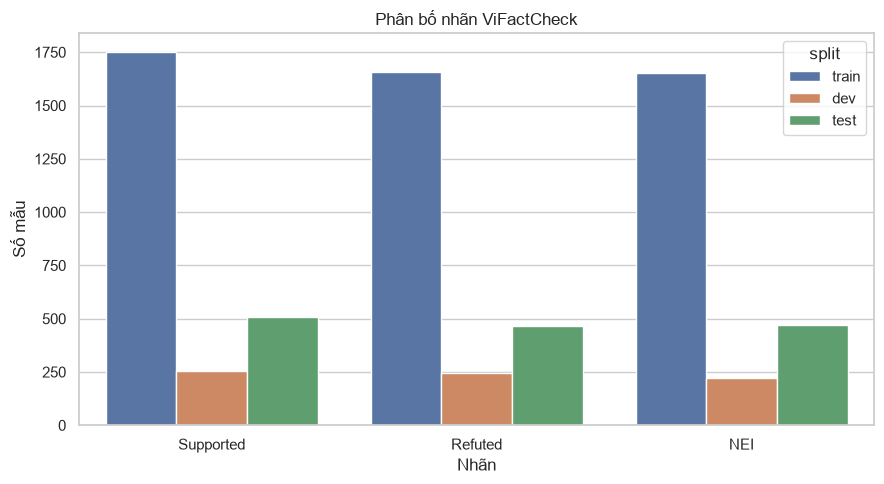

**Nhận xét từ lần chạy này:** Tổng 7,232 mẫu. Chênh lệch nhãn lớn nhất và nhỏ nhất trên Train là 1.94 điểm phần trăm. Dùng Macro-F1 làm tiêu chí chọn cấu hình; Accuracy và các metric macro đều được báo cáo. Baseline hiện tại dùng class_weight=None.

In [5]:
split_overview = pd.DataFrame([
    {"split": s, "num_samples": len(df), "source_columns": raw_shapes[s][1],
     "columns_after_label_mapping": raw_shapes[s][1] + 1, "columns_with_source_row": len(df.columns)}
    for s, df in data.items()])
split_overview["percent"] = split_overview.num_samples / split_overview.num_samples.sum() * 100
save_csv(split_overview, "01_split_overview.csv")
display(split_overview)
label_stats = pd.DataFrame([
    {"split": s, "label": label, "count": int((df[LABEL_COL] == label).sum()),
     "percent": float((df[LABEL_COL] == label).mean() * 100)}
    for s, df in data.items() for label in LABEL_ORDER])
save_csv(label_stats, "02_label_distribution.csv")
display(label_stats.round(2))
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=label_stats, x="label", y="count", hue="split", order=LABEL_ORDER, ax=ax)
ax.set(title="Phân bố nhãn ViFactCheck", xlabel="Nhãn", ylabel="Số mẫu")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "02_label_distribution.png", dpi=180); plt.show(); plt.close(fig)
train_pct = label_stats.query("split == 'train'").set_index('label')['percent']
note(f"Tổng {sum(map(len, data.values())):,} mẫu. Chênh lệch nhãn lớn nhất và nhỏ nhất trên Train là "
     f"{train_pct.max()-train_pct.min():.2f} điểm phần trăm. Dùng Macro-F1 làm tiêu chí chọn cấu hình; "
     "Accuracy và các metric macro đều được báo cáo. Baseline hiện tại dùng class_weight=None.")


### C2 Missing và blank — mục 3.2.4 Kiểm tra chất lượng dữ liệu
Đếm null riêng với chuỗi chỉ chứa khoảng trắng. Không tự điền bằng chứng giả. Nếu Test thiếu nhãn, dừng trước đánh giá để tránh âm thầm thay đổi tập đánh giá.


In [6]:
quality_missing = []
for split, frame in data.items():
    for column in required_columns:
        null = frame[column].isna()
        blank = frame[column].notna() & frame[column].astype(str).str.strip().eq("")
        quality_missing.append({"split": split, "field": column, "missing_count": int(null.sum()),
                                "blank_non_null_count": int(blank.sum())})
missing_stats = pd.DataFrame(quality_missing)
save_csv(missing_stats, "03_missing_values.csv"); display(missing_stats)
note(f"Có {missing_stats.missing_count.sum()} giá trị null và "
     f"{missing_stats.blank_non_null_count.sum()} ô blank không-null trong bốn trường khảo sát. "
     "Đây là kiểm tra tính đầy đủ, không chứng minh văn bản hoặc nhãn hoàn toàn chính xác.")


,split,field,missing_count,blank_non_null_count
0,train,statement,0,0
1,train,context,0,0
2,train,evidence,0,0
3,train,label_name,0,0
4,dev,statement,0,0
5,dev,context,0,0
6,dev,evidence,0,0
7,dev,label_name,0,0
8,test,statement,0,0
9,test,context,0,0


**Nhận xét từ lần chạy này:** Có 0 giá trị null và 0 ô blank không-null trong bốn trường khảo sát. Đây là kiểm tra tính đầy đủ, không chứng minh văn bản hoặc nhãn hoàn toàn chính xác.

### C3 Trùng dữ liệu và giao nhau giữa các split — mục 3.2.4
`keep=False` đếm mọi dòng thuộc nhóm trùng, không phải số dòng dư. Kiểm tra cặp giống hệt, Statement giống hệt và nhãn xung đột; chưa đánh giá trùng ngữ nghĩa. Giữ nguyên split chung cho vòng chạy này.


In [7]:
duplicate_stats = pd.DataFrame([
    {"split": s, "full_duplicate_rows": int(df.duplicated(required_columns, keep=False).sum()),
     "statement_evidence_duplicate_rows": int(df.duplicated([STATEMENT_COL, EVIDENCE_COL], keep=False).sum()),
     "duplicate_pair_extra_rows": int(df.duplicated([STATEMENT_COL, EVIDENCE_COL]).sum())}
    for s, df in data.items()])
save_csv(duplicate_stats, "04_duplicates.csv"); display(duplicate_stats)
overlap_rows = []
for a, b in combinations(data, 2):
    keys_a = set(zip(data[a].statement, data[a].evidence))
    keys_b = set(zip(data[b].statement, data[b].evidence))
    shared = data[a].merge(data[b], on=[STATEMENT_COL, EVIDENCE_COL], suffixes=(f"_{a}", f"_{b}"))
    overlap_rows.append({"split_a": a, "split_b": b, "exact_pairs": len(keys_a & keys_b),
                         "shared_statements": len(set(data[a].statement) & set(data[b].statement)),
                         "conflicting_pair_rows": int((shared[f"label_name_{a}"] != shared[f"label_name_{b}"]).sum())})
    save_csv(shared, f"04_{a}_{b}_overlap.csv")
overlap_summary = pd.DataFrame(overlap_rows)
save_csv(overlap_summary, "04_overlap_summary.csv"); display(overlap_summary)
# Hiển thị nhãn để kiểm chứng nhận xét Statement chung dù Evidence khác.
shared_statements = train_df.merge(dev_df, on=STATEMENT_COL, suffixes=("_train", "_dev"))
display(shared_statements[[STATEMENT_COL, "evidence_train", "evidence_dev", "label_name_train", "label_name_dev"]])
note(f"Tổng {overlap_summary.exact_pairs.sum()} cặp trùng tuyệt đối giữa các cặp split. "
     "Giữ nguyên dữ liệu để đồng nhất với nhóm và ghi nhận nguy cơ đánh giá lạc quan; "
     "nếu nhóm thay split, tất cả mô hình phải dùng cùng phiên bản mới.")


,split,full_duplicate_rows,statement_evidence_duplicate_rows,duplicate_pair_extra_rows
0,train,0,0,0
1,dev,0,0,0
2,test,0,0,0


,split_a,split_b,exact_pairs,shared_statements,conflicting_pair_rows
0,train,dev,0,1,0
1,train,test,1,1,0
2,dev,test,0,0,0


,statement,evidence_train,evidence_dev,label_name_train,label_name_dev
0,Đây là vụ hoả hoạn nghiêm trọng thứ ba trong lịch sử Cuba khi tàn phá 4 trong số 8 bể chứa tại kho nhiên liệu lớn nhất cả nước.,Đây là vụ hỏa hoạn nghiêm trọng nhất trong lịch sử Cuba và được coi là thảm họa công nghiệp có nguồn gốc tự nhiên lớn nhất từ trước tới nay. tàn phá 4 trong...,"tàn phá 4 trong số 8 bể chứa tại kho nhiên liệu bên vịnh Matanzas, Đây là vụ hỏa hoạn nghiêm trọng nhất trong lịch sử Cuba và được coi là thảm họa công nghi...",Refuted,Refuted


**Nhận xét từ lần chạy này:** Tổng 1 cặp trùng tuyệt đối giữa các cặp split. Giữ nguyên dữ liệu để đồng nhất với nhóm và ghi nhận nguy cơ đánh giá lạc quan; nếu nhóm thay split, tất cả mô hình phải dùng cùng phiên bản mới.

### C4 Độ dài văn bản và số Evidence — mục 3.2.3 Phân tích đặc điểm văn bản
Thống kê ký tự và token theo khoảng trắng trên cả ba split. Đây chưa phải token của Underthesea hay subword của Transformer; không dùng trực tiếp các giá trị này làm max_length cho Transformer.


,split,field,unit,count,mean,std,min,50%,75%,90%,95%,99%,max
0,train,statement,char,5062.0,161.25,68.11,30.0,151.0,196.00,243.0,280.0,375.78,739.0
1,train,statement,whitespace_token,5062.0,35.84,14.96,7.0,34.0,43.00,54.0,62.0,84.00,165.0
2,train,context,char,5062.0,3177.60,1722.15,314.0,2840.0,3957.00,5406.0,6186.0,9449.00,16369.0
3,train,context,whitespace_token,5062.0,693.16,374.96,71.0,608.0,865.00,1177.0,1337.0,2074.00,3602.0
4,train,evidence,char,5062.0,196.62,101.92,6.0,178.0,239.75,323.0,383.0,540.56,1205.0
5,train,evidence,whitespace_token,5062.0,43.35,22.24,2.0,39.0,53.00,71.0,85.0,119.00,259.0
6,dev,statement,char,723.0,160.11,71.02,42.0,151.0,194.00,243.8,281.9,383.34,672.0
7,dev,statement,whitespace_token,723.0,35.55,15.58,10.0,34.0,43.00,54.0,62.0,86.56,145.0
8,dev,context,char,723.0,3071.13,1558.75,314.0,2739.0,3881.50,5220.0,5923.7,8189.24,11436.0
9,dev,context,whitespace_token,723.0,670.14,339.29,71.0,597.0,846.00,1147.6,1298.0,1787.52,2534.0


,split,distinct_evidence_per_statement,num_statements
0,train,1,5058
1,train,2,2
2,dev,1,723
3,test,1,1447


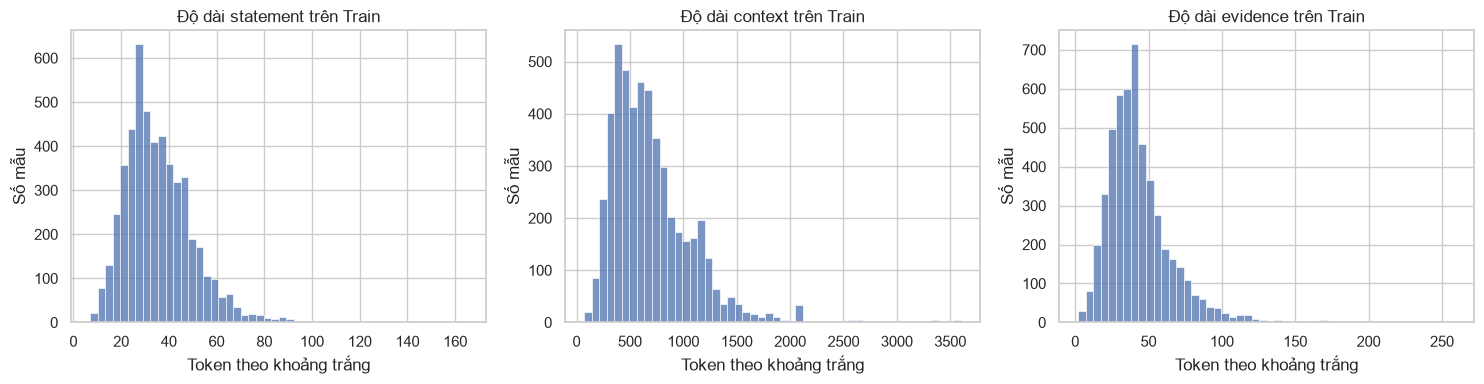

**Nhận xét từ lần chạy này:** Trung vị Train: statement 34; context 608; evidence 39. Evidence là chuỗi: đếm số chuỗi khác nhau trên mỗi Statement, không tách số câu bằng dấu chấm. Context dài hơn giúp nhóm IR/Transformer tham khảo; baseline vẫn dùng Gold Evidence theo phân công.

In [8]:
length_rows, evidence_rows = [], []
for split, frame in data.items():
    for column in TEXT_COLS:
        text = frame[column].fillna("")
        for unit, lengths in [("char", text.str.len()), ("whitespace_token", text.str.split().str.len())]:
            row = lengths.describe(percentiles=[.5, .75, .9, .95, .99]).to_dict()
            length_rows.append({"split": split, "field": column, "unit": unit, **row})
    counts = frame.groupby(STATEMENT_COL)[EVIDENCE_COL].nunique()
    for count, n_statements in counts.value_counts().sort_index().items():
        evidence_rows.append({"split": split, "distinct_evidence_per_statement": int(count),
                              "num_statements": int(n_statements)})
length_summary_all = pd.DataFrame(length_rows)
evidence_distribution = pd.DataFrame(evidence_rows)
save_csv(length_summary_all, "05_text_length_summary_all.csv")
save_csv(length_summary_all.query("split == 'train' and unit == 'whitespace_token'"), "05_text_length_summary_train.csv")
save_csv(evidence_distribution, "05_evidence_count_distribution.csv")
display(length_summary_all.round(2)); display(evidence_distribution)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for column, ax in zip(TEXT_COLS, axes):
    sns.histplot(train_df[column].fillna("").str.split().str.len(), bins=50, ax=ax)
    ax.set(title=f"Độ dài {column} trên Train", xlabel="Token theo khoảng trắng", ylabel="Số mẫu")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "05_text_length_histograms.png", dpi=180); plt.show(); plt.close(fig)
summary_train = length_summary_all.query("split == 'train' and unit == 'whitespace_token'").set_index('field')
note("Trung vị Train: " + "; ".join(f"{c} {summary_train.loc[c, '50%']:.0f}" for c in TEXT_COLS) +
     ". Evidence là chuỗi: đếm số chuỗi khác nhau trên mỗi Statement, không tách số câu bằng dấu chấm. "
     "Context dài hơn giúp nhóm IR/Transformer tham khảo; baseline vẫn dùng Gold Evidence theo phân công.")


### C5 Ký tự và định dạng bất thường — mục 3.2.4
Bổ sung kiểm tra ký tự thay thế, ký tự vô hình và Unicode chưa ở dạng NFC. Chỉ phát hiện và lưu mẫu, không tự sửa nội dung ngôn ngữ.


In [9]:
quality_patterns = {"has_url": r"https?://\S+|www\.\S+", "has_html": r"<[^>]+>",
                    "has_repeated_space": r"\s{2,}", "replacement_character": "\ufffd",
                    "zero_width_character": "[\u200b\u200c\u200d\ufeff]"}
quality_rows, issue_samples = [], []
for split, frame in data.items():
    for column in TEXT_COLS:
        text = frame[column].fillna("")
        masks = {name: text.str.contains(pattern, regex=True) for name, pattern in quality_patterns.items()}
        masks['not_nfc'] = text.map(lambda s: unicodedata.normalize("NFC", s) != s)
        for issue, mask in masks.items():
            quality_rows.append({"split": split, "field": column, "issue": issue, "count": int(mask.sum())})
            for idx in frame.index[mask][:3]:
                issue_samples.append({"split": split, "source_row": int(frame.at[idx,'source_row']),
                                      "field": column, "issue": issue, "text": frame.at[idx,column]})
quality_report = pd.DataFrame(quality_rows)
save_csv(quality_report, "06_text_quality_report.csv")
save_csv(pd.DataFrame(issue_samples, columns=['split','source_row','field','issue','text']), "06_quality_examples.csv")
display(quality_report.pivot_table(index=['split','field'], columns='issue', values='count'))
note("URL được đếm theo số ô có khớp mẫu. Kiểm tra regex không nhận ra mọi lỗi ngôn ngữ, chẳng hạn từ dính “vàchôn”. "
     "Không gọi dữ liệu hoàn toàn sạch chỉ từ kiểm tra null/regex.")


issue            has_html  has_repeated_space  has_url  not_nfc  \
split field                                                       
dev   context         0.0                 0.0     15.0      0.0   
      evidence        0.0                 0.0      1.0      0.0   
      statement       0.0                 0.0      1.0      0.0   
test  context         0.0                 0.0     33.0      0.0   
      evidence        0.0                 0.0      2.0      0.0   
      statement       0.0                 0.0      2.0      0.0   
train context         0.0                 0.0    120.0      0.0   
      evidence        0.0                 0.0      4.0      0.0   
      statement       0.0                 0.0      2.0      0.0   

issue            replacement_character  zero_width_character  
split field                                                   
dev   context                      0.0                   0.0  
      evidence                     0.0                   0.0  
      statement                    0.0                   0.0  
test  context                      0.0                   0.0  
      evidence                     0.0                   0.0  
      statement                    0.0                   0.0  
train context                      0.0                   0.0  
      evidence                     0.0                   0.0  
      statement                    0.0                   0.0

**Nhận xét từ lần chạy này:** URL được đếm theo số ô có khớp mẫu. Kiểm tra regex không nhận ra mọi lỗi ngôn ngữ, chẳng hạn từ dính “vàchôn”. Không gọi dữ liệu hoàn toàn sạch chỉ từ kiểm tra null/regex.

### 3.3. Output

Báo cáo thống kê dataset: 7.232 mẫu thuộc ba tập Train/Dev/Test, với ba nhãn khá cân bằng. Các mục C1–C5 trình bày cấu trúc, phân bố nhãn, độ dài, số Evidence, giá trị thiếu, trùng lặp và định dạng bất thường. Đây là thống kê trên common_cleaned; chưa đánh giá tác động làm sạch so với raw.

Quyết định preprocessing: giữ các mẫu hợp lệ và split chung; lưu văn bản gốc để truy vết. Làm sạch Unicode, URL, HTML, khoảng trắng và tách từ; thử riêng lowercase, dấu câu và chuẩn hóa từ vựng trên Dev. Giữ số và phủ định, chưa loại stopwords. Nhãn khá cân bằng nên dùng class_weight=None và đánh giá bằng các metric macro cùng Accuracy. Chi tiết ở mục 4.1.

Cơ sở lựa chọn mô hình: TF-IDF + Logistic Regression là baseline đơn giản theo thiết kế đồ án, dùng đo tín hiệu từ vựng của cặp Statement–Evidence trước khi so sánh với mô hình ngữ cảnh. EDA không chứng minh đây là mô hình tốt nhất; cấu hình tiền xử lý và n-gram phải được chọn bằng Dev.

Cơ sở thiết kế pipeline: dùng Statement + Gold Evidence để đánh giá riêng NLI. Context dài trung bình khoảng 16 lần Evidence gợi ý chia câu/đoạn trước truy hồi trong pipeline IR → IE/reranking → NLI của nhóm. Đây là định hướng, chưa phải kết quả thực nghiệm IR/IE của TV1. Max length Transformer cần kiểm tra bằng tokenizer riêng và tỷ lệ cắt trên Train/Dev. Chỉ fit Train, chọn bằng Dev, báo cáo Test; ghi nhận trùng split khi diễn giải.

Các nhận xét này gắn với ba CSV common_cleaned hiện tại; khi đổi dữ liệu, cần đối chiếu lại với bảng EDA của lần chạy mới. Định hướng mô hình và pipeline không thay thế việc đánh giá thực nghiệm.


## 4.1. Preprocessing cho TF-IDF + Logistic Regression

Input: Statement và Gold Evidence trong ba tập common_cleaned. Xử lý hai vế riêng theo cùng cấu hình, giữ dữ liệu gốc để truy vết.

| Bước | Áp dụng | Lý do | Công cụ / Phương pháp |
|---|---|---|---|
| Làm sạch dữ liệu | Có; mọi cấu hình | Loại nhiễu kỹ thuật; giữ văn bản gốc để truy vết. | Python Regex và Unicode NFC; bỏ HTML/URL, gộp khoảng trắng. |
| Chuẩn hóa từ vựng | Có; thử ở P5 | Giảm biến thể chính tả, ổn định vocabulary. | Từ điển cố định: hoà→hòa, hoá→hóa, thuỷ→thủy, xoá→xóa, toà→tòa, khoẻ→khỏe. |
| Tách từ | Có; mọi cấu hình | Tạo token tiếng Việt rõ ràng cho TF-IDF. | Underthesea; nối từ ghép bằng dấu gạch dưới. |
| Loại stopwords | Thử nghiệm; P4 chưa chạy | Có thể giảm nhiễu nhưng làm mất thông tin kiểm chứng. | Stopword list: chưa có danh sách đã kiểm tra; chưa có kết quả P4. |
| Xóa dấu câu | Có; thử ở P3 | Giảm đặc trưng không cần thiết, kiểm tra tác động trên Dev. | Python Regex bỏ phần lớn dấu câu; giữ dấu chấm, phẩy và %. |
| Lowercase | Có; thử giữ và không giữ | Giảm biến thể; có thể mất dấu hiệu tên riêng, tổ chức, viết tắt. | Python .lower(): P2/P3/P5; P1 giữ hoa thường. |

P1 làm sạch và tách từ; P2 thêm lowercase; P3 thêm xử lý dấu câu so với P2; P5 thêm chuẩn hóa từ vựng so với P2. Các lựa chọn được so sánh bằng Dev. P4 mới có mã cấu hình; thử loại stopwords chưa hoàn tất. Không mặc định chuẩn hóa từ vựng hay xóa dấu câu cải thiện kết quả.

Giữ chữ số và phủ định; không sửa chính tả tổng quát. Regex dấu câu giữ dấu chấm, phẩy, phần trăm nhưng có thể làm mất dấu nối ngày tháng. TF-IDF tiếp tục tách định dạng số: giữ chữ số không có nghĩa giữ nguyên dữ kiện.


In [10]:
# Tạo biểu thức chính quy nhận diện URL.
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")

# Tạo biểu thức chính quy nhận diện thẻ HTML.
HTML_PATTERN = re.compile(r"<[^>]+>")

# Tạo biểu thức chính quy nhận diện khoảng trắng lặp.
SPACE_PATTERN = re.compile(r"\s+")

# Tạo biểu thức xóa phần lớn dấu câu nhưng giữ dấu chấm, dấu phẩy và phần trăm gắn với dữ kiện số.
PUNCT_PATTERN = re.compile(r"[^\w\s%.,]", flags=re.UNICODE)

# Tạo hàm làm sạch văn bản có tham số để phục vụ thí nghiệm.
LEXICAL_MAP = {"hoà": "hòa", "hoá": "hóa", "thuỷ": "thủy", "xoá": "xóa", "toà": "tòa", "khoẻ": "khỏe"}
LEXICAL_PATTERN = re.compile(r"\b(?:" + "|".join(map(re.escape, LEXICAL_MAP)) + r")\b")

def preprocess_text(text, lowercase=False, remove_punctuation=False, remove_stopwords=False, stopwords=None, normalize_lexical=False):
    # Kiểm tra trường hợp một ô chứa danh sách nhiều đoạn Evidence.
    if isinstance(text, (list, tuple, np.ndarray)):
        # Ghép các đoạn Evidence thành một chuỗi, không tự chia theo dấu câu.
        text = " ".join(str(item) for item in text)
    # Xử lý trường hợp một ô chỉ chứa một giá trị thông thường.
    else:
        # Đổi null thành chuỗi rỗng, còn giá trị hợp lệ thành chuỗi.
        text = "" if pd.isna(text) else str(text)
    # Chuẩn hóa Unicode về NFC để các ký tự tiếng Việt có cùng biểu diễn mã.
    text = unicodedata.normalize("NFC", text)
    # Thay URL bằng khoảng trắng vì URL thường là nhiễu đối với baseline này.
    text = URL_PATTERN.sub(" ", text)
    # Thay thẻ HTML bằng khoảng trắng.
    text = HTML_PATTERN.sub(" ", text)
    # Đưa về chữ thường nếu cấu hình thí nghiệm yêu cầu.
    if lowercase:
        # Chuyển toàn bộ văn bản sang chữ thường.
        text = text.lower()
    if normalize_lexical:
        text = LEXICAL_PATTERN.sub(lambda match: LEXICAL_MAP[match.group(0)], text)
    # Xóa dấu câu nếu cấu hình thí nghiệm yêu cầu.
    if remove_punctuation:
        # Thay phần lớn dấu câu bằng khoảng trắng nhưng vẫn giữ chữ, số, dấu thập phân và phần trăm.
        text = PUNCT_PATTERN.sub(" ", text)
    # Tách từ tiếng Việt và nối từ ghép bằng dấu gạch dưới.
    text = word_tokenize(text, format="text")
    # Xóa stopwords nếu cấu hình thí nghiệm yêu cầu.
    if remove_stopwords:
        # Bảo đảm danh sách stopwords đã được truyền vào.
        if not stopwords:
            raise ValueError("Bật stopwords cần danh sách không rỗng đã được kiểm tra")
        stopwords = set(stopwords)
        protected = {"không", "chưa", "chẳng", "chả", "đừng", "không_phải", "chưa_từng"}
        if protected & {word.lower() for word in stopwords}:
            raise ValueError("Stopword list chứa từ phủ định cần giữ")
        # Chỉ giữ token không nằm trong danh sách stopwords.
        text = " ".join(token for token in text.split() if token not in stopwords)
    # Gộp mọi khoảng trắng lặp thành một khoảng trắng.
    text = SPACE_PATTERN.sub(" ", text).strip()
    # Trả về văn bản đã xử lý.
    return text


In [11]:
# Cấu hình P1 chỉ làm sạch lỗi kỹ thuật và tách từ.
PREPROCESSING_CONFIGS = {
    "P1_clean_segment": {
        "lowercase": False,
        "remove_punctuation": False,
        "remove_stopwords": False,
    },
    # Cấu hình P2 bổ sung lowercase.
    "P2_lower": {
        "lowercase": True,
        "remove_punctuation": False,
        "remove_stopwords": False,
    },
    # Cấu hình P3 bổ sung lowercase và xóa dấu câu.
    "P3_lower_no_punct": {
        "lowercase": True,
        "remove_punctuation": True,
        "remove_stopwords": False,
    },
    # Cấu hình P4 dành cho thí nghiệm stopwords; chỉ bật khi đã có danh sách được kiểm tra.
    "P4_lower_no_punct_no_stop": {
        "lowercase": True,
        "remove_punctuation": True,
        "remove_stopwords": True,
    },
}

# Tạo hàm xử lý riêng Statement và Evidence rồi ghép lại.
def build_model_text(df, config, stopwords=None):
    # Xử lý từng Statement theo cấu hình.
    processed_statement = df[STATEMENT_COL].apply(
        lambda value: preprocess_text(value, stopwords=stopwords, **config)
    )
    # Xử lý từng Evidence theo cùng cấu hình.
    processed_evidence = df[EVIDENCE_COL].apply(
        lambda value: preprocess_text(value, stopwords=stopwords, **config)
    )
    # Ghép Statement và Evidence thành một chuỗi đầu vào theo đúng yêu cầu baseline.
    combined_text = processed_statement + " " + processed_evidence
    # Gộp khoảng trắng và bỏ khoảng trắng hai đầu sau khi ghép.
    combined_text = combined_text.str.replace(r"\s+", " ", regex=True).str.strip()
    # Trả về ba Series để vừa huấn luyện vừa có thể kiểm tra từng phần.
    return processed_statement, processed_evidence, combined_text


PREPROCESSING_CONFIGS["P5_lower_lexical"] = dict(PREPROCESSING_CONFIGS["P2_lower"], normalize_lexical=True)


### D1 Kiểm tra trước và sau tiền xử lý
Ví dụ lấy từ Train. P3 chỉ là cấu hình minh họa ở đây, chưa phải cấu hình thắng Dev. Kiểm tra số, phủ định, tên riêng trên chuỗi và trên token thực tế.


In [12]:
EXPERIMENT_CONFIGS = ["P1_clean_segment", "P2_lower", "P3_lower_no_punct", "P5_lower_lexical"]
examples = train_df.head(20)
comparison_rows = []
for name in EXPERIMENT_CONFIGS:
    st, ev, combined = build_model_text(examples, PREPROCESSING_CONFIGS[name])
    for idx in examples.index:
        comparison_rows.append({"config": name, "source_row": int(examples.at[idx,'source_row']),
            "statement_raw": examples.at[idx,STATEMENT_COL], "statement_processed": st.loc[idx],
            "evidence_raw": examples.at[idx,EVIDENCE_COL], "evidence_processed": ev.loc[idx], "model_text": combined.loc[idx]})
comparison = pd.DataFrame(comparison_rows)
save_csv(comparison, "07_preprocessing_examples.csv"); display(comparison.head(3))
TOKEN_PATTERN = r"(?u)\b\w+\b"
tokenizer_probe = TfidfVectorizer(lowercase=False, token_pattern=TOKEN_PATTERN).build_analyzer()
probe = "Việt Nam không tăng 6.5% ngày 25/3/2023, mà giảm 8%."
probe_rows = []
for name in EXPERIMENT_CONFIGS:
    processed = preprocess_text(probe, **PREPROCESSING_CONFIGS[name])
    tokens = tokenizer_probe(processed)
    assert "không" in tokens and "8" in tokens, "Mất phủ định hoặc token số một ký tự"
    probe_rows.append({"config": name, "raw": probe, "processed": processed, "tfidf_tokens": tokens})
display(pd.DataFrame(probe_rows))
save_csv(pd.DataFrame(probe_rows), "07_tokenization_probe.csv")
note("Quan sát cột tfidf_tokens để thấy dấu % và dấu phân cách không còn là đặc trưng riêng. "
     "Khi P3 xóa dấu câu trước tách từ, một số ranh giới từ cũng có thể thay đổi. "
     "Không kết luận rằng P1 đưa toàn bộ dấu câu vào vector chỉ vì không bật remove_punctuation.")


lexical_counts = pd.DataFrame([{"variant": old, "canonical": new, "train_occurrences": sum(train_df[col].fillna("").str.lower().map(lambda text: len(re.findall(r"\b" + re.escape(old) + r"\b", unicodedata.normalize("NFC", text)))).sum() for col in [STATEMENT_COL, EVIDENCE_COL])} for old, new in LEXICAL_MAP.items()])
display(lexical_counts)
save_csv(lexical_counts, "07_lexical_normalization_train.csv")
assert LEXICAL_PATTERN.sub(lambda m: LEXICAL_MAP[m.group(0)], "hoà toàn 6.5% không") == "hòa toàn 6.5% không"


,config,source_row,statement_raw,statement_processed,evidence_raw,evidence_processed,model_text
0,P1_clean_segment,0,"Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các...","Phó Thủ_tướng Trần_Hồng_Hà thay_mặt Chính_phủ , Thủ_tướng Chính_phủ chúc_mừng Đài_Truyền_hình Việt_Nam , Đài_truyền_hình các tỉnh , thành_phố trên cả nước ,...","Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, cá...","Thay_mặt Chính_phủ , Thủ_tướng Chính_phủ , Phó Thủ_tướng Trần_Hồng_Hà chúc_mừng Đài_Truyền_hình Việt_Nam , Đài_truyền_hình các tỉnh , thành_phố trên cả nước...","Phó Thủ_tướng Trần_Hồng_Hà thay_mặt Chính_phủ , Thủ_tướng Chính_phủ chúc_mừng Đài_Truyền_hình Việt_Nam , Đài_truyền_hình các tỉnh , thành_phố trên cả nước ,..."
1,P1_clean_segment,1,"Hành vi của Tô Văn Hải là cho phép người khác đổ chất thải rắn ra môi trường vàchôn, lấp chất thải trái phép.","Hành_vi của Tô_Văn_Hải là cho_phép người khác đổ chất_thải rắn ra môi_trường vàchôn , lấp chất_thải trái_phép .","Tô Văn Hải đã có hành vi cho phép người khác đổ, thải chất thải rắn thông thường ra môi trường Giáo). Sau đó, Hải tiến hành chôn, lấp tổng khối lượng 642.07...","Tô_Văn_Hải đã có hành_vi cho_phép người khác đổ , thải chất_thải rắn thông_thường ra môi_trường_Giáo ) . Sau đó , Hải tiến_hành chôn , lấp tổng khối_lượng 6...","Hành_vi của Tô_Văn_Hải là cho_phép người khác đổ chất_thải rắn ra môi_trường vàchôn , lấp chất_thải trái_phép . Tô_Văn_Hải đã có hành_vi cho_phép người khác..."
2,P1_clean_segment,2,"SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác bảo trì, bảo dưỡng định kỳ Nhà máy nước Tân Hiệp, thời gian thực hiện dự kiến từ 12 giờ ngày ...","SAWACO thông_báo tạm ngưng cung_cấp nước để thực_hiện công_tác bảo_trì , bảo_dưỡng định_kỳ Nhà_máy nước Tân_Hiệp , thời_gian thực_hiện dự_kiến từ 12 giờ ngà...",SAWACO thông báo tạm ngưng cung cấp nước để thực hiện công tác nêu trên. Thời gian thực hiện dự kiến từ 22 giờ ngày 25-3 (thứ bảy) đến 4 giờ ngày 26-3 (chủ ...,SAWACO thông_báo tạm ngưng cung_cấp nước để thực_hiện công_tác nêu trên . Thời_gian thực_hiện dự_kiến từ 22 giờ ngày 25-3 ( thứ_bảy ) đến 4 giờ ngày 26-3 ( ...,"SAWACO thông_báo tạm ngưng cung_cấp nước để thực_hiện công_tác bảo_trì , bảo_dưỡng định_kỳ Nhà_máy nước Tân_Hiệp , thời_gian thực_hiện dự_kiến từ 12 giờ ngà..."


,config,raw,processed,tfidf_tokens
0,P1_clean_segment,"Việt Nam không tăng 6.5% ngày 25/3/2023, mà giảm 8%.","Việt_Nam không tăng 6.5 % ngày 25/3/2023 , mà giảm 8 % .","[Việt_Nam, không, tăng, 6, 5, ngày, 25, 3, 2023, mà, giảm, 8]"
1,P2_lower,"Việt Nam không tăng 6.5% ngày 25/3/2023, mà giảm 8%.","việt_nam không tăng 6.5 % ngày 25/3/2023 , mà giảm 8 % .","[việt_nam, không, tăng, 6, 5, ngày, 25, 3, 2023, mà, giảm, 8]"
2,P3_lower_no_punct,"Việt Nam không tăng 6.5% ngày 25/3/2023, mà giảm 8%.","việt_nam không tăng 6.5 % ngày 25 3 2023 , mà giảm 8 % .","[việt_nam, không, tăng, 6, 5, ngày, 25, 3, 2023, mà, giảm, 8]"
3,P5_lower_lexical,"Việt Nam không tăng 6.5% ngày 25/3/2023, mà giảm 8%.","việt_nam không tăng 6.5 % ngày 25/3/2023 , mà giảm 8 % .","[việt_nam, không, tăng, 6, 5, ngày, 25, 3, 2023, mà, giảm, 8]"


**Nhận xét từ lần chạy này:** Quan sát cột tfidf_tokens để thấy dấu % và dấu phân cách không còn là đặc trưng riêng. Khi P3 xóa dấu câu trước tách từ, một số ranh giới từ cũng có thể thay đổi. Không kết luận rằng P1 đưa toàn bộ dấu câu vào vector chỉ vì không bật remove_punctuation.

,variant,canonical,train_occurrences
0,hoà,hòa,19
1,hoá,hóa,32
2,thuỷ,thủy,2
3,xoá,xóa,0
4,toà,tòa,7
5,khoẻ,khỏe,6


### 4.1. Output

Đầu ra là Statement và Evidence đã preprocessing, cùng chuỗi ghép làm input cho mục 5.1.
- `07_processed_train.csv`, `07_processed_dev.csv`, `07_processed_test.csv`: `statement_processed`, `evidence_processed`, `model_text`, dữ liệu gốc và `source_row`.
- `07_preprocessing_examples.csv`: ví dụ trước–sau ở P3; `07_tokenization_probe.csv`: kiểm tra dữ kiện qua preprocessing và TF-IDF.
- `07_lexical_normalization_train.csv`: số lần khớp biến thể từ vựng; `07_filter_report.csv`: số mẫu giữ/loại.
- `vifactcheck_preprocessing.py`: mã dùng lại, xuất trong phần H.

Các tệp nằm trong `OUTPUT_DIR` của lần chạy. Ba file processed dùng cấu hình thắng Dev và chỉ được xuất tại E3; vị trí cell xuất sau bước lựa chọn không làm thay đổi vai trò của chúng là output preprocessing. Chưa có output thực nghiệm P4.


## 5.1. TF-IDF + Logistic Regression

### Input
Statement + Evidence đã preprocessing, cột `model_text` từ mục 4.1. Không đưa Context, nhãn hoặc metadata vào văn bản.

### Phương pháp
TF-IDF Vectorization bằng `TfidfVectorizer`: mỗi hàng là một mẫu, mỗi cột là token/n-gram; vector được chuẩn hóa L2.

### Công việc theo PDF
1. Xây vocabulary từ Train, không dùng Dev/Test để học vocabulary.
2. Tính TF-IDF weight cho từng token; IDF chỉ học từ Train.
3. Thử unigram `(1,1)` và unigram + bigram `(1,2)` cho P1/P2/P3/P5; chọn bằng Dev Macro-F1.
4. Transform Train/Dev/Test thành vector theo vocabulary và IDF đã học, lưu ma trận thưa.

### Flow
Text → Token → TF-IDF Vector → Logistic Regression → Label.
Mục 5.1 tạo vector, mục 6.3.1 huấn luyện và dự đoán nhãn. Cell E2 thực hiện chung vector hóa và fit Logistic Regression để dùng lại Pipeline; cell E3 xuất output sau khi chọn cấu hình bằng Dev.

### E1 Dữ liệu hợp lệ và bộ nhớ đệm tiền xử lý
Không dùng Context, topic, author, URL nguồn hoặc chỉ mục làm đặc trưng. Test phải đầy đủ input và nhãn; nếu không thì dừng. Tiền xử lý Train/Dev được tính một lần cho mỗi cấu hình, dùng lại giữa hai n-gram.


In [13]:
model_data, filter_rows = {}, []
for split, frame in data.items():
    valid = pd.Series(True, index=frame.index)
    for column in [STATEMENT_COL, EVIDENCE_COL, LABEL_COL]:
        valid &= frame[column].notna() & frame[column].fillna("").astype(str).str.strip().ne("")
    filter_rows.append({"split": split, "before": len(frame), "kept": int(valid.sum()), "removed": int((~valid).sum())})
    if split == 'test':
        assert valid.all(), "Test có mẫu không hợp lệ; cần thống nhất tập đánh giá, không âm thầm loại"
    model_data[split] = frame.loc[valid].copy().reset_index(drop=True)
    assert set(model_data[split][LABEL_COL]) == set(LABEL_ORDER), f"{split}: thiếu lớp để đánh giá ba nhãn"
filter_report = pd.DataFrame(filter_rows)
save_csv(filter_report, '07_filter_report.csv'); display(filter_report)
text_cache = {}
for name in EXPERIMENT_CONFIGS:
    for split in ['train', 'dev']:
        st, ev, combined = build_model_text(model_data[split], PREPROCESSING_CONFIGS[name])
        assert st.str.strip().ne('').all() and ev.str.strip().ne('').all(), f"{name}/{split}: text rỗng sau xử lý"
        text_cache[(name, split)] = (st, ev, combined)
    print('Đã tiền xử lý:', name)


,split,before,kept,removed
0,train,5062,5062,0
1,dev,723,723,0
2,test,1447,1447,0


Đã tiền xử lý: P1_clean_segment


Đã tiền xử lý: P2_lower


Đã tiền xử lý: P3_lower_no_punct


Đã tiền xử lý: P5_lower_lexical


### E2 Biểu diễn TF-IDF và nguyên tắc học
TF-IDF tạo ma trận thưa: mỗi hàng là một cặp Statement–Evidence, mỗi cột là token hoặc n-gram trong vocabulary. Tần suất token kết hợp với IDF làm giảm trọng số của token quá phổ biến; vector được chuẩn hóa L2. Vocabulary và IDF **chỉ học từ Train**.

Unigram bỏ qua thứ tự token và vai trò của hai vế. Bigram thêm hai token liền nhau nhưng không biểu diễn trực tiếp phép đối chiếu số liệu hay quan hệ suy luận. Hai vế nối bằng khoảng trắng nên bigram có thể bắc qua ranh giới ghép.

Tám cấu hình gồm sáu cấu hình gốc và hai cấu hình P5; Logistic Regression dùng `max_iter=1000`, `C=1`, `solver='lbfgs'`, `class_weight=None`, seed 42. Lưu cảnh báo hội tụ; nếu có cấu hình chưa hội tụ, dừng trước chọn mô hình để tránh so sánh không đầy đủ. Không tự tăng số vòng lặp sau khi xem Test.


In [14]:
def run_experiment(config_name, ngram_range):
    x_train = text_cache[(config_name, 'train')][2]
    x_dev = text_cache[(config_name, 'dev')][2]
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=ngram_range, lowercase=False, token_pattern=TOKEN_PATTERN)),
        ('classifier', LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', class_weight=None,
                                           random_state=RANDOM_STATE))])
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', ConvergenceWarning)
        pipeline.fit(x_train, model_data['train'][LABEL_COL])
    convergence_messages = [str(w.message) for w in caught if issubclass(w.category, ConvergenceWarning)]
    for warning in caught:
        if not issubclass(warning.category, ConvergenceWarning):
            print(type(warning.message).__name__, str(warning.message))
    predicted = pipeline.predict(x_dev)
    result = {'config': config_name, 'ngram_range': str(ngram_range), 'class_weight': 'None',
              **metrics(model_data['dev'][LABEL_COL], predicted),
              'vocab_size': len(pipeline.named_steps['tfidf'].vocabulary_),
              'max_n_iter': int(pipeline.named_steps['classifier'].n_iter_.max()),
              'converged': not bool(convergence_messages), 'convergence_warning': ' | '.join(convergence_messages)}
    return pipeline, result
trained_pipelines, experiment_results = {}, []
for name in EXPERIMENT_CONFIGS:
    for ngram in [(1,1), (1,2)]:
        pipe, row = run_experiment(name, ngram)
        key = f'{name}_{ngram}'
        row['experiment_key'] = key
        trained_pipelines[key] = pipe
        experiment_results.append(row)
        print(key, 'Dev Macro-F1:', round(row['macro_f1'], 6))
# Stable sort giữ thứ tự thử khi hai cấu hình bằng điểm.
results_df = pd.DataFrame(experiment_results).sort_values('macro_f1', ascending=False, kind='stable').reset_index(drop=True)
save_csv(results_df, '08_dev_experiment_results.csv'); display(results_df)
assert results_df.converged.all(), 'Có mô hình chưa hội tụ. Xem cảnh báo và điều chỉnh bằng Train/Dev trước khi chạy Test.'
best_row = results_df.iloc[0]
best_key = best_row.experiment_key
best_config_name = best_row['config']
best_config = PREPROCESSING_CONFIGS[best_config_name].copy()
best_pipeline = trained_pipelines[best_key]
note(f"Dev chọn **{best_key}**, Accuracy {best_row.accuracy:.2%}, Macro-F1 {best_row.macro_f1:.2%}. "
     "P4/stopwords và balanced chưa được thử; không kết luận hiệu quả của chúng.")
for name in EXPERIMENT_CONFIGS:
    group = results_df[results_df.config.eq(name)].set_index('ngram_range')
    delta = 100 * (group.loc['(1, 2)','macro_f1'] - group.loc['(1, 1)','macro_f1'])
    print(f'{name}: thêm bigram làm Macro-F1 thay đổi {delta:+.2f} điểm phần trăm trên Dev.')

for ng in ["(1, 1)", "(1, 2)"]:
    scores = results_df[results_df.ngram_range.eq(ng)].set_index("config").macro_f1
    note(f"Chuẩn hóa từ vựng P5 so với P2 với n-gram {ng}: Macro-F1 Dev thay đổi {100*(scores["P5_lower_lexical"]-scores["P2_lower"]):+.2f} điểm phần trăm. Đây là so sánh cùng các tham số còn lại; không mặc định chuẩn hóa luôn tốt hơn.")


P1_clean_segment_(1, 1) Dev Macro-F1: 0.390805


P1_clean_segment_(1, 2) Dev Macro-F1: 0.374351


P2_lower_(1, 1) Dev Macro-F1: 0.36755


P2_lower_(1, 2) Dev Macro-F1: 0.347317
P3_lower_no_punct_(1, 1) Dev Macro-F1: 0.362259


P3_lower_no_punct_(1, 2) Dev Macro-F1: 0.351635


...

,config,ngram_range,class_weight,accuracy,macro_precision,macro_recall,macro_f1,vocab_size,max_n_iter,converged,convergence_warning,experiment_key
0,P1_clean_segment,"(1, 1)",None,0.392808,0.390178,0.392450,0.390805,15293,59,True,,"P1_clean_segment_(1, 1)"
1,P1_clean_segment,"(1, 2)",None,0.376210,0.373751,0.375734,0.374351,130574,39,True,,"P1_clean_segment_(1, 2)"
2,P2_lower,"(1, 1)",None,0.369295,0.367035,0.369866,0.367550,13120,53,True,,"P2_lower_(1, 1)"
3,P5_lower_lexical,"(1, 1)",None,0.369295,0.367035,0.369866,0.367550,13120,53,True,,"P5_lower_lexical_(1, 1)"
4,P3_lower_no_punct,"(1, 1)",None,0.363762,0.361935,0.363951,0.362259,13205,39,True,,"P3_lower_no_punct_(1, 1)"
5,P3_lower_no_punct,"(1, 2)",None,0.354080,0.350923,0.353489,0.351635,123722,32,True,,"P3_lower_no_punct_(1, 2)"
6,P2_lower,"(1, 2)",None,0.349931,0.346907,0.349004,0.347317,123662,33,True,,"P2_lower_(1, 2)"
7,P5_lower_lexical,"(1, 2)",None,0.349931,0.346907,0.349004,0.347317,123662,33,True,,"P5_lower_lexical_(1, 2)"


**Nhận xét từ lần chạy này:** Dev chọn **P1_clean_segment_(1, 1)**, Accuracy 39.28%, Macro-F1 39.08%. P4/stopwords và balanced chưa được thử; không kết luận hiệu quả của chúng.

P1_clean_segment: thêm bigram làm Macro-F1 thay đổi -1.65 điểm phần trăm trên Dev.
P2_lower: thêm bigram làm Macro-F1 thay đổi -2.02 điểm phần trăm trên Dev.
P3_lower_no_punct: thêm bigram làm Macro-F1 thay đổi -1.06 điểm phần trăm trên Dev.
P5_lower_lexical: thêm bigram làm Macro-F1 thay đổi -2.02 điểm phần trăm trên Dev.


**Nhận xét từ lần chạy này:** Chuẩn hóa từ vựng P5 so với P2 với n-gram (1, 1): Macro-F1 Dev thay đổi +0.00 điểm phần trăm. Đây là so sánh cùng các tham số còn lại; không mặc định chuẩn hóa luôn tốt hơn.

**Nhận xét từ lần chạy này:** Chuẩn hóa từ vựng P5 so với P2 với n-gram (1, 2): Macro-F1 Dev thay đổi +0.00 điểm phần trăm. Đây là so sánh cùng các tham số còn lại; không mặc định chuẩn hóa luôn tốt hơn.

### E3 Quan sát ma trận đặc trưng thực tế
Chỉ sau khi chọn cấu hình bằng Dev mới chuẩn bị Test. Hiển thị kích thước, độ thưa, tỷ lệ hàng toàn 0 và token có trọng số trong một mẫu Train; không đổi ma trận thưa toàn bộ sang dense.


In [15]:
st, ev, combined = build_model_text(model_data['test'], best_config)
assert st.str.strip().ne('').all() and ev.str.strip().ne('').all(), 'Test rỗng sau xử lý'
text_cache[(best_config_name,'test')] = (st, ev, combined)
tfidf = best_pipeline.named_steps['tfidf']
vocab_before = tfidf.vocabulary_.copy()
idf_before = tfidf.idf_.copy()
feature_matrices, feature_rows = {}, []
for split in ['train','dev','test']:
    processed_statement, processed_evidence, model_text = text_cache[(best_config_name,split)]
    matrix = tfidf.transform(model_text)
    assert sparse.issparse(matrix) and matrix.shape[1] == len(vocab_before)
    feature_matrices[split] = matrix
    feature_rows.append({'split': split, 'rows': matrix.shape[0], 'features': matrix.shape[1],
                         'nnz': int(matrix.nnz), 'density': matrix.nnz / (matrix.shape[0]*matrix.shape[1]),
                         'zero_vector_rows': int((matrix.getnnz(axis=1)==0).sum())})
    sparse.save_npz(OUTPUT_DIR / f'08_tfidf_{split}.npz', matrix)
    processed_df = model_data[split].copy()
    processed_df['statement_processed'] = processed_statement
    processed_df['evidence_processed'] = processed_evidence
    processed_df['model_text'] = model_text
    save_csv(processed_df, f'07_processed_{split}.csv')
assert tfidf.vocabulary_ == vocab_before
np.testing.assert_array_equal(tfidf.idf_, idf_before)
feature_report = pd.DataFrame(feature_rows)
save_csv(feature_report, '08_feature_matrix_summary.csv'); display(feature_report)
feature_names = tfidf.get_feature_names_out()
first = feature_matrices['train'].getrow(0)
order = np.argsort(first.data)[::-1][:15]
display(pd.DataFrame({'token': feature_names[first.indices[order]], 'tfidf': first.data[order]}))
note(f"Cấu hình thắng có {len(feature_names):,} đặc trưng. Transform Dev/Test không đổi vocabulary hoặc IDF. "
     "Ma trận chỉ thể hiện dấu hiệu từ vựng, không tự xác định quan hệ giữa hai vế.")


,split,rows,features,nnz,density,zero_vector_rows
0,train,5062,15293,174798,0.002258,0
1,dev,723,15293,24061,0.002176,0
2,test,1447,15293,47941,0.002166,0


,token,tfidf
0,Thủ_tướng,0.295582
1,Chính_phủ,0.286291
2,Đài_Truyền_hình,0.259835
3,Đài_truyền_hình,0.252715
4,gián_đoạn,0.230599
5,chúc_mừng,0.227557
6,Hải_Phòng,0.213668
7,truyền_hình,0.204023
8,Trần_Hồng_Hà,0.193485
9,đại_dịch,0.183324


**Nhận xét từ lần chạy này:** Cấu hình thắng có 15,293 đặc trưng. Transform Dev/Test không đổi vocabulary hoặc IDF. Ma trận chỉ thể hiện dấu hiệu từ vựng, không tự xác định quan hệ giữa hai vế.

### 5.1. Output

**Ma trận TF-IDF đưa vào Logistic Regression**, lưu tại `OUTPUT_DIR`:
- `08_tfidf_train.npz`, `08_tfidf_dev.npz`, `08_tfidf_test.npz`.
- `08_feature_matrix_summary.csv`: kích thước, số phần tử khác 0, density và số hàng vector toàn 0.
- `08_dev_experiment_results.csv`: kết quả so sánh unigram/bigram và cấu hình preprocessing.

Vocabulary và IDF được lưu trong bước `tfidf` của `tfidf_logistic_regression_pipeline.joblib` và `vifactcheck_bundle.joblib` ở phần H. Với lần chạy 20260912T150042_282820Z, P1 unigram tạo 15.293 đặc trưng, kích thước Train/Dev/Test lần lượt 5.062×15.293, 723×15.293 và 1.447×15.293; không có vector toàn 0. Khi chạy lại, dùng bảng E3 và manifest của lần chạy mới làm nguồn số liệu.


## 6.3.1. TF-IDF + Logistic Regression

Input là vector TF-IDF của Statement + Gold Evidence; mô hình Logistic Regression xuất nhãn Supported, Refuted hoặc NEI. Output gồm classification result (nhãn dự đoán từng mẫu) và baseline performance (Accuracy, Precision, Recall, Macro-F1, confusion matrix). Huấn luyện và chọn cấu hình ở E2; các cell F đánh giá cấu hình đã chọn. Áp dụng chiến lược Train/Dev/Test và metric chung của mục 6.4–6.5.
Train để fit, Dev để lựa chọn, Test để báo cáo. Không fit lại trên Train+Dev trong quy trình này. Các nhận xét dưới đây được sinh từ dự đoán mới thay vì sao chép số liệu cũ.


### 6.3.1. Output
`10_test_predictions.csv` lưu nhãn dự đoán từng mẫu; `09_test_metrics.csv`, `09_classification_report_test.csv` và `09_confusion_matrix_test.csv/.png` lưu hiệu quả baseline. Các tệp xuất trong `OUTPUT_DIR`; mô hình tái sử dụng nằm trong bundle bàn giao ở phần H.


In [16]:
y_test = model_data['test'][LABEL_COL]
x_test = text_cache[(best_config_name,'test')][2]
y_test_pred = best_pipeline.predict(x_test)
test_metrics = metrics(y_test, y_test_pred)
report = pd.DataFrame(classification_report(y_test, y_test_pred, labels=LABEL_ORDER,
                                          output_dict=True, zero_division=0)).T
save_csv(pd.DataFrame([{'experiment_key': best_key, **test_metrics}]), '09_test_metrics.csv')
save_csv(report, '09_classification_report_test.csv', index=True)
display(pd.DataFrame([test_metrics])); display(report)
majority_label = model_data['train'][LABEL_COL].value_counts().idxmax()
majority_metrics = metrics(y_test, np.repeat(majority_label, len(y_test)))
save_csv(pd.DataFrame([{'baseline':'train_majority','label':majority_label, **majority_metrics}]), '09_majority_baseline.csv')
best_label = report.loc[LABEL_ORDER, 'f1-score'].idxmax()
weak_label = report.loc[LABEL_ORDER, 'f1-score'].idxmin()
note(f"Accuracy {test_metrics['accuracy']:.2%}, Macro-F1 {test_metrics['macro_f1']:.2%}. "
     f"F1 cao nhất: {best_label}; thấp nhất: {weak_label}. "
     f"Mốc luôn đoán nhãn đông nhất trên Train ({majority_label}) đạt Accuracy {majority_metrics['accuracy']:.2%}; "
     f"chênh lệch là {100*(test_metrics['accuracy']-majority_metrics['accuracy']):+.2f} điểm phần trăm. "
     f"Test Macro-F1 so với Dev thay đổi {100*(test_metrics['macro_f1']-best_row.macro_f1):+.2f} điểm phần trăm.")


,accuracy,macro_precision,macro_recall,macro_f1
0,0.386317,0.381322,0.383511,0.38111


,precision,recall,f1-score,support
Supported,0.422222,0.486220,0.451967,508.000000
Refuted,0.341523,0.297009,0.317714,468.000000
NEI,0.380220,0.367304,0.373650,471.000000
accuracy,0.386317,0.386317,0.386317,0.386317
macro avg,0.381322,0.383511,0.381110,1447.000000
weighted avg,0.382450,0.386317,0.383054,1447.000000


**Nhận xét từ lần chạy này:** Accuracy 38.63%, Macro-F1 38.11%. F1 cao nhất: Supported; thấp nhất: Refuted. Mốc luôn đoán nhãn đông nhất trên Train (Supported) đạt Accuracy 35.11%; chênh lệch là +3.52 điểm phần trăm. Test Macro-F1 so với Dev thay đổi -0.97 điểm phần trăm.

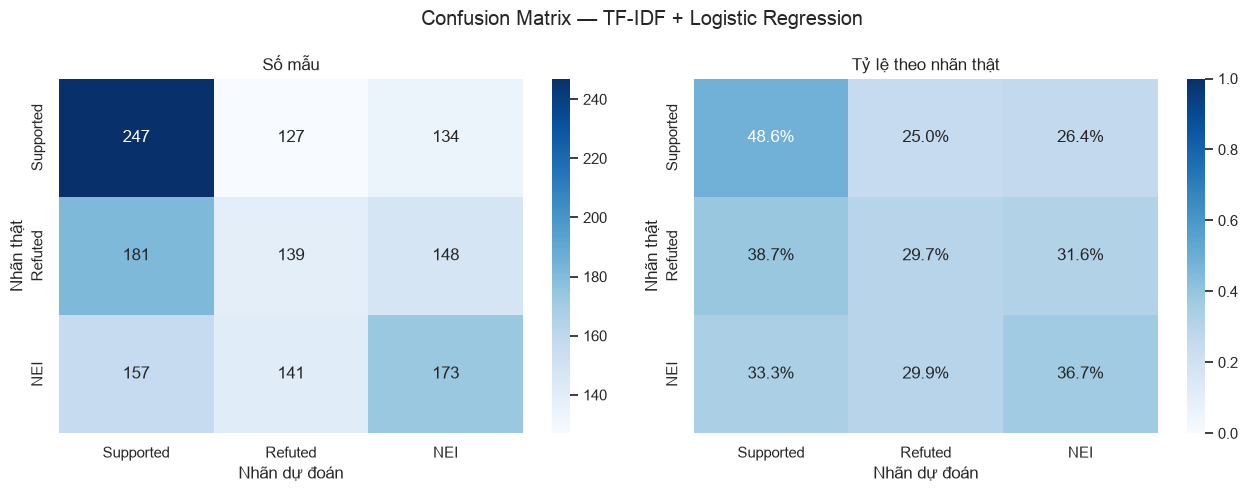

,label_name,predicted_label,error_count
3,Refuted,Supported,181
1,NEI,Supported,157
2,Refuted,NEI,148
0,NEI,Refuted,141
4,Supported,NEI,134
5,Supported,Refuted,127


**Nhận xét từ lần chạy này:** Có 888 mẫu sai trên 1447 mẫu. Hướng nhầm lớn nhất là Refuted → Supported: 181 mẫu. Ma trận mô tả hành vi nhầm nhãn; nguyên nhân ngôn ngữ cần đọc từng cặp Statement–Evidence.

In [17]:
cm = confusion_matrix(y_test, y_test_pred, labels=LABEL_ORDER)
assert cm.sum() == len(y_test)
cm_df = pd.DataFrame(cm, index=LABEL_ORDER, columns=LABEL_ORDER)
save_csv(cm_df, '09_confusion_matrix_test.csv', index=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=axes[0])
sns.heatmap(cm_df.div(cm_df.sum(axis=1),axis=0), annot=True, fmt='.1%', cmap='Blues', vmin=0, vmax=1, ax=axes[1])
for ax, title in zip(axes, ['Số mẫu', 'Tỷ lệ theo nhãn thật']):
    ax.set(title=title, xlabel='Nhãn dự đoán', ylabel='Nhãn thật')
fig.suptitle('Confusion Matrix — TF-IDF + Logistic Regression')
fig.tight_layout(); fig.savefig(OUTPUT_DIR/'09_confusion_matrix_test.png',dpi=180); plt.show(); plt.close(fig)
test_predictions = model_data['test'][['source_row',STATEMENT_COL,EVIDENCE_COL,LABEL_COL]].copy()
test_predictions['predicted_label'] = y_test_pred
test_predictions['is_correct'] = test_predictions[LABEL_COL].eq(test_predictions.predicted_label)
error_cases = test_predictions.loc[~test_predictions.is_correct].copy()
save_csv(test_predictions, '10_test_predictions.csv'); save_csv(error_cases, '11_error_cases.csv')
confusion_pairs = (error_cases.groupby([LABEL_COL,'predicted_label']).size().reset_index(name='error_count')
                   .sort_values('error_count',ascending=False))
save_csv(confusion_pairs, '12_confusion_pairs.csv'); display(confusion_pairs)
assert confusion_pairs.error_count.sum() == len(error_cases)
if not confusion_pairs.empty:
    largest = confusion_pairs.iloc[0]
    note(f"Có {len(error_cases)} mẫu sai trên {len(y_test)} mẫu. Hướng nhầm lớn nhất là "
         f"{largest[LABEL_COL]} → {largest.predicted_label}: {largest.error_count} mẫu. "
         "Ma trận mô tả hành vi nhầm nhãn; nguyên nhân ngôn ngữ cần đọc từng cặp Statement–Evidence.")
else:
    note('Không có mẫu sai trong lần chạy này.')


## G Phân tích lỗi bổ trợ cho mục 6.3.1
Lấy tối đa 10 mẫu theo từng hướng nhầm, seed 42. Đây là mẫu phân tầng theo hướng nhầm, **không phải mẫu ngẫu nhiên đại diện tỷ lệ lỗi toàn Test**. Các nhóm lỗi và giải thích là phân tích định tính, chưa chứng minh cơ chế nhân quả bên trong mô hình.

Bản notebook mang theo 60 ghi chú từ `13_error_analysis_completed.xlsx` của dự án để đọc được độc lập. Khi kết quả chạy mới khác, chỉ sử dụng ghi chú có **Statement, Evidence, nhãn thật và dự đoán trùng khớp**; không tự gán ghi chú cũ cho dự đoán khác. Không sửa file phân tích gốc.


Cột `gold_label_explanation` là diễn giải theo nhãn được cấp, chưa phải thẩm định lại nhãn. Cột `baseline_failure_reason` là giả thuyết của người đọc. Đặc biệt, nếu mô hình thắng là unigram, các ghi chú nhắc thay đổi bigram không giải thích trực tiếp dự đoán của mô hình đó; đề xuất bigram phải đối chiếu kết quả Dev đã có.

In [18]:
sample_groups = [g.sample(n=min(10,len(g)),random_state=RANDOM_STATE)
                 for _, g in error_cases.groupby([LABEL_COL,'predicted_label'])]
error_analysis_sample = (pd.concat(sample_groups,ignore_index=True) if sample_groups else error_cases.iloc[:0].copy())
annotation_cols = ['error_type','gold_label_explanation','baseline_failure_reason','suggested_adjustment']
for column in annotation_cols:
    error_analysis_sample[column] = ''
save_csv(error_analysis_sample, '13_error_analysis_sample.csv')
print('Số mẫu cần đọc:', len(error_analysis_sample))


Số mẫu cần đọc: 60


In [19]:
# Ghi chú định tính từ lần chạy gốc; không phải nhãn lỗi tự sinh.
original_error_notes = [{'statement': 'Do mặt hàng dầu mazut giảm quá mạnh nên đã được tăng trích từ 0 đồng lên 300 đồng/lít.', 'evidence': 'riêng mặt hàng dầu mazut tăng trích từ 0 đồng lên 300 đồng/lít.', 'label_name': 'NEI', 'predicted_label': 'Refuted', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence chỉ xác nhận dầu mazut được tăng mức trích từ 0 lên 300 đồng/lít; không nêu nguyên nhân là do giá giảm quá mạnh. Vì phần nguyên nhân chưa được chứng minh, nhãn đúng là NEI.', 'baseline_failure_reason': 'Cụm từ về mức trích xuất hiện gần như giống nhau làm mô hình nghiêng sang Refuted, nhưng mô hình không tách được phần sự kiện đã có bằng chứng và phần nguyên nhân bị thêm vào.', 'suggested_adjustment': 'Giữ ranh giới rõ giữa Statement và Evidence; thử unigram + bigram và giữ các từ quan hệ như ‘do’, ‘nên’ để mô hình nhận diện phần nguyên nhân.'}, {'statement': 'Những người có tiền sử gia đình mắc bệnh ung thư gan sẽ có nguy cơ mắc bệnh thấp hơn.', 'evidence': 'còn có một số yếu tố nguy cơ khác như nhiễm độc tố Alfatoxin, Dioxin, bệnh gan di truyền, bệnh gan nhiễm mỡ, béo phì, đái tháo đường, uống nhiều rượu…', 'label_name': 'NEI', 'predicted_label': 'Refuted', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence liệt kê các yếu tố nguy cơ ung thư gan nhưng không nói tiền sử gia đình làm nguy cơ thấp hơn hay cao hơn. Do đó chưa thể xác nhận hoặc bác bỏ phát biểu.', 'baseline_failure_reason': 'Mô hình bắt được các từ ‘nguy cơ’, ‘ung thư gan’ rồi suy ra có mâu thuẫn, dù Evidence không đề cập trực tiếp quan hệ với tiền sử gia đình.', 'suggested_adjustment': 'Giữ cụm từ đầy đủ bằng bigram; khi báo cáo, ghi rõ đây là giới hạn của TF-IDF vì chỉ dựa mạnh vào từ xuất hiện chung.'}, {'statement': 'Đây cũng là năm đầu tiên Báo Thể thao và Văn hóa áp dụng công nghệ Blockchain vào công tác tổ chức và phát hành những NFT, tài sản ảo đại diện cho những hình ảnh, video clip độc bản, video độc quyền của những đề cử và của Giải thưởng Cống hiến”, ông Lê Xuân Thành cho biết.', 'evidence': 'Đây cũng là năm đầu tiên Báo Thể thao và Văn hóa áp dụng công nghệ Blockchain vào công tác tổ chức và phát hành những NFT, tài sản ảo đại diện cho những hình ảnh, video clip độc bản của những đề cử và của Giải thưởng Cống hiến”, ông Lê Xuân Thành cho biết.', 'label_name': 'NEI', 'predicted_label': 'Refuted', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence xác nhận việc phát hành NFT đại diện cho hình ảnh và video clip độc bản, nhưng không xác nhận chi tiết ‘video độc quyền’. Phần bổ sung này làm mẫu thuộc NEI.', 'baseline_failure_reason': 'Độ trùng từ rất cao khiến một chi tiết nhỏ bị thêm vào không được mô hình tuyến tính nhận ra.', 'suggested_adjustment': 'Dùng bigram và giữ dấu câu; kiểm tra trọng số của các cụm quanh ‘độc quyền’ thay vì chỉ dựa vào độ trùng từ tổng thể.'}, {'statement': 'Chánh văn phòng Trung tâm Đào tạo - Chỉ đạo tuyến, Bệnh viện Phụ sản Trung ương TP.HCM- ThS.BS Phan Chí Thành cho biết gia đình xin bác sĩ thuốc "hãm" vì cụ ông ngoài 60 vẫn thèm chuyện ấy.', 'evidence': 'ThS.BS Phan Chí Thành - Chánh văn phòng Trung tâm Đào tạo - Chỉ đạo tuyến, Bệnh viện Phụ sản Trung ương Gia đình xin bác sĩ thuốc "hãm" vì cụ ông ngoài 60 vẫn thèm chuyện ấy', 'label_name': 'NEI', 'predicted_label': 'Refuted', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence xác nhận chức vụ, tên bác sĩ và nội dung gia đình xin thuốc, nhưng không nêu ‘TP.HCM’. Vì địa điểm bổ sung không được chứng minh, nhãn đúng là NEI.', 'baseline_failure_reason': 'Hầu hết từ khóa chính đều trùng nên mô hình xem phần địa điểm bổ sung là không đáng kể.', 'suggested_adjustment': 'Giữ nguyên tên riêng và dấu câu; dùng bigram để tăng khả năng nhận ra cụm địa điểm và phần thông tin được thêm vào.'}, {'statement': 'Trong cấu trúc doanh thu Phúc Long, doanh thu từ trà chiếm tỷ lệ cao nhất, đứng nhì là cà phê, đứng thứ ba là sữa.', 'evidence': 'Trong cấu trúc doanh thu Phúc Long, doanh thu từ trà chiếm hơn 70% nhờ thương hiệu được yêu thích.', 'label_name': 'NEI', 'predicted_label': 'Refuted', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence chỉ nói doanh thu trà chiếm hơn 70%; không cho biết cà phê đứng thứ hai và sữa đứng thứ ba. Vì thứ hạng còn lại thiếu bằng chứng, nhãn đúng là NEI.', 'baseline_failure_reason': 'Mô hình bị chi phối bởi cụm ‘cấu trúc doanh thu’, ‘Phúc Long’ và ‘trà’, trong khi bỏ qua hai quan hệ xếp hạng không có trong Evidence.', 'suggested_adjustment': 'Giữ các từ chỉ thứ hạng và thử bigram như ‘đứng nhì’, ‘đứng thứ’; trình bày đây là lỗi của biểu diễn bag-of-words.'}, {'statement': 'Bản sao của bộ xương hóa thách được tìm thấy sau khoảng 10 năm khai quật.', 'evidence': 'bản sao bộ xương hóa thạch của một trong 6 con titanosaur được tìm thấy sau khi một nông dân ở vùng Argentina phát hiện ra một xương đùi khổng lồ nhô ra khỏi mặt đất vào năm 2010, dẫn đến quá trình khai quật kéo dài nhiều năm.', 'label_name': 'NEI', 'predicted_label': 'Refuted', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Evidence nói bộ xương được phát hiện năm 2010 và quá trình khai quật kéo dài nhiều năm, nhưng không xác nhận con số khoảng 10 năm. Vì thời lượng cụ thể chưa đủ bằng chứng, nhãn đúng là NEI.', 'baseline_failure_reason': 'Mô hình nhận thấy nội dung khai quật tương tự nhưng không liên kết được mốc năm với khoảng thời gian được suy ra.', 'suggested_adjustment': 'Không xóa số; giữ cụm thời gian và dùng bigram để các biểu thức ‘10 năm’, ‘năm 2010’, ‘nhiều năm’ được biểu diễn rõ hơn.'}, {'statement': 'Sau khi nhận tem máy từ Liều, ông Chín đục lại số máy trên máy cũ thành số máy mới bằng cách sử dụng công nghệ hiện đại học từ nước ngoài.', 'evidence': 'Sau khi nhận tem máy từ Liều, ông Chín đục lại số máy trên máy cũ thành số máy mới,', 'label_name': 'NEI', 'predicted_label': 'Refuted', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence xác nhận ông Chín đục lại số máy sau khi nhận tem, nhưng không nói ông dùng công nghệ hiện đại học từ nước ngoài. Phần phương thức này chưa được chứng minh nên là NEI.', 'baseline_failure_reason': 'Phần đầu Statement gần như chép lại Evidence, làm các từ bổ sung ở cuối câu bị lấn át.', 'suggested_adjustment': 'Giữ dấu câu và bigram; phân tích riêng phần bổ sung sau cụm ‘bằng cách’ khi giải thích lỗi.'}, {'statement': 'Bắt đầu từ ngày 18/3 đến hết ngày 20/5, công an sẽ mở cao điểm cấp Căn căn cước công dân gắn chíp kết hợp cấp tài khoản định danh điện tử cho toàn bộ công dân trong độ tuổi sinh năm 2004, 2005, 2007, 2008 thi tuyển sinh ngày 1/7/2023 chưa được cấp Căn cước công dân gắn chíp điện tử.', 'evidence': 'bắt đầu từ ngày 18/3 đến hết ngày 20/5, công an sẽ mở cao điểm cấp Căn căn cước công dân gắn chíp kết hợp cấp tài khoản định danh điện tử cho toàn bộ công dân trong độ tuổi thi tuyển sinh năm 2023 chưa cấp Căn cước công dân gắn chíp điện tử bộ công dân sinh năm 2004, 2005, 2007, 2008. Cụ', 'label_name': 'NEI', 'predicted_label': 'Refuted', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Evidence có giai đoạn 18/3–20/5 và nhóm năm sinh, nhưng không xác nhận chi tiết kỳ thi diễn ra ngày 1/7/2023. Vì mốc ngày bổ sung thiếu bằng chứng, nhãn đúng là NEI.', 'baseline_failure_reason': 'Nhiều số và ngày gần nhau làm TF-IDF khó xác định mốc nào thuộc sự kiện nào.', 'suggested_adjustment': 'Giữ nguyên ngày, năm và dấu gạch; thử bigram để gắn mốc thời gian với cụm sự kiện tương ứng.'}, {'statement': 'Trong các phương thức xét tuyển thì chỉ tiêu cho đánh giá năng lực là nhiều nhất, hơn 40% tổng chỉ tiêu tuyển sinh của trường.', 'evidence': 'Các phương thức tuyển sinh của Đại học Quốc gia Hà Nội cơ bản ổn định, gồm xét theo điểm thi tốt nghiệp THPT; xét bằng điểm thi đánh giá năng lực; bằng các kỳ thi, chứng chỉ quốc tế kết hợp với học bạ; xét tuyển học sinh các trường chuyên, THPT thuộc Đại học Quốc gia Hà Nội. Theo ông Đức, chỉ tiêu xét tuyển từ điểm thi đánh giá năng lực có thể tăng lên so với mức 20% của năm 2022.', 'label_name': 'NEI', 'predicted_label': 'Refuted', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Evidence chỉ cho biết chỉ tiêu theo điểm đánh giá năng lực có thể tăng so với mức 20% năm 2022; không xác nhận mức hơn 40% hay đây là chỉ tiêu lớn nhất. Nhãn đúng là NEI.', 'baseline_failure_reason': 'Các từ về phương thức xét tuyển trùng nhiều, còn quan hệ so sánh ‘hơn 40%’ và ‘nhiều nhất’ không được mô hình xử lý tốt.', 'suggested_adjustment': 'Không xóa số và từ so sánh; dùng bigram cho ‘hơn 40%’, ‘nhiều nhất’, ‘tăng lên’.'}, {'statement': 'Gần 11.400 máy tính bảng được Chủ tịch nước trao tặng học sinh vùng sâu, vùng xa trong tỉnh Kon Tum vào chiều 7/3.', 'evidence': 'Gần 11.400 máy tính bảng được trao tặng học sinh vùng sâu, vùng xa trong tỉnh Kon Tum vào chiều 7/3.', 'label_name': 'NEI', 'predicted_label': 'Refuted', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence xác nhận gần 11.400 máy tính bảng được trao cho học sinh Kon Tum vào 7/3, nhưng không nêu người trao là Chủ tịch nước. Thiếu thông tin về chủ thể nên là NEI.', 'baseline_failure_reason': 'Số lượng, đối tượng, địa điểm và thời gian đều trùng nên chi tiết chủ thể bị mô hình bỏ qua.', 'suggested_adjustment': 'Giữ tên chức danh và bigram; kiểm tra các trường hợp thêm hoặc đổi chủ thể trong tập lỗi.'}, {'statement': 'Bộ GD&ĐT vừa ra quyết định về việc điều chỉnh liên kết tổ chức thi cấp chứng chỉ tiếng Anh IELTS vào ngày 6/7 vừa qua.', 'evidence': 'Bộ GD&ĐT vừa ra quyết định về việc điều chỉnh liên kết tổ chức thi cấp chứng chỉ tiếng Anh IELTS', 'label_name': 'NEI', 'predicted_label': 'Supported', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Evidence xác nhận Bộ GD&ĐT ra quyết định điều chỉnh liên kết thi IELTS nhưng không có ngày 6/7. Vì mốc ngày chưa được chứng minh, nhãn đúng là NEI.', 'baseline_failure_reason': 'Độ trùng từ cao khiến mốc thời gian bổ sung không đủ làm thay đổi dự đoán Supported.', 'suggested_adjustment': 'Giữ ngày tháng và thử bigram; không loại số hoặc dấu gạch chéo trong preprocessing.'}, {'statement': 'Trước khi có cơ sở chính thức ở quận 1, Trường Trưng Vương tạm tổ chức các hoạt động dạy và học tại Trường Gia Long do quyết định của quan chức cấp cao thời đó.', 'evidence': 'Trong khi chưa có cơ sở học chính thức, Trường Trưng Vương tạm tổ chức các hoạt động dạy và học tại Trường Gia Long Trường Nữ Trung Học Trưng Vương chính thức được chuyển về số 3 đường Nguyễn Bỉnh Khiêm, Q.1', 'label_name': 'NEI', 'predicted_label': 'Supported', 'error_type': 'Quan hệ nhân quả / quan hệ', 'gold_label_explanation': 'Evidence nói Trường Trưng Vương tạm học tại Trường Gia Long khi chưa có cơ sở chính thức, nhưng không nêu nguyên nhân là quyết định của quan chức cấp cao. Vì quan hệ nguyên nhân thiếu bằng chứng, nhãn đúng là NEI.', 'baseline_failure_reason': 'TF-IDF nhận ra các thực thể và hành động giống nhau nhưng không biểu diễn được quan hệ nguyên nhân được thêm vào.', 'suggested_adjustment': 'Giữ các từ chỉ quan hệ như ‘do’, ‘vì’; dùng bigram và nêu rõ giới hạn của mô hình bag-of-words.'}, {'statement': 'Phó Thủ tướng Lê Minh Khái và Bí thư thứ nhất Trung ương Đoàn Bùi Quang Huy đã trao cúp vô địch cho đội Đại học Huế và giải Nhì cho ĐH Thủy Lợi.', 'evidence': 'Phó Thủ tướng Lê Minh Khái và Bí thư thứ nhất Trung ương Đoàn Bùi Quang Huy đã trao cúp vô địch cho đội Đại học Huế', 'label_name': 'NEI', 'predicted_label': 'Supported', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence xác nhận đội Đại học Huế nhận cúp vô địch, nhưng không nói ĐH Thủy Lợi nhận giải Nhì. Một phần của phát biểu chưa được chứng minh nên là NEI.', 'baseline_failure_reason': 'Mô hình bị chi phối bởi phần đầu hoàn toàn trùng với Evidence và bỏ qua mệnh đề bổ sung.', 'suggested_adjustment': 'Giữ liên từ ‘và’ cùng dấu câu; thử bigram để nhận biết phát biểu gồm nhiều mệnh đề cần được kiểm chứng.'}, {'statement': 'Trường ĐH Ngoại ngữ -Tin học TPHCM đã trao đổi với phóng viên Dân trí rằng chương trình hội thảo về khởi nghiệp này nằm trong chuỗi hoạt động về chủ đề khởi nghiệp do Đoàn hội các trường phối hợp với Hội sinh viên và Nhà Văn hóa sinh viên TPHCM tổ chức vào tháng 2/2023.', 'evidence': 'Trao đổi với PV Dân trí về sự việc gây xôn xao, đại diện Trường ĐH Ngoại ngữ -Tin học TPHCM cho biết, chương trình hội thảo về khởi nghiệp này nằm trong chuỗi hoạt động về chủ đề khởi nghiệp do Đoàn hội các trường phối hợp với Hội sinh viên và Nhà Văn hóa sinh viên TPHCM tổ chức.', 'label_name': 'NEI', 'predicted_label': 'Supported', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Evidence xác nhận nội dung, đơn vị phối hợp và chuỗi hoạt động khởi nghiệp, nhưng không nêu thời điểm tháng 2/2023. Do đó nhãn đúng là NEI.', 'baseline_failure_reason': 'Các cụm dài trùng nhau làm mốc thời gian bổ sung bị lấn át.', 'suggested_adjustment': 'Không xóa số và ngày; dùng bigram cho cụm tháng/năm và giữ ranh giới Statement–Evidence.'}, {'statement': 'Weploy - mô hình cung ứng nhân sự thời vụ trên nền tảng số gây sốt khi xuất hiện tại thị trường Việt Nam hỗ trợ cho doanh nghiệp tuyển dụng.', 'evidence': 'chính thức có mặt tại Việt Nam sau khi thành công ở vòng gọi vốn đầu tiên với 5 triệu USD từ Skymind Global Ventures. Weploy - mô hình cung ứng nhân sự thời vụ trên nền tảng số', 'label_name': 'NEI', 'predicted_label': 'Supported', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence xác nhận Weploy là mô hình cung ứng nhân sự thời vụ trên nền tảng số tại Việt Nam; không xác nhận ‘gây sốt’ hoặc tác dụng hỗ trợ tuyển dụng như phát biểu. Nhãn đúng là NEI.', 'baseline_failure_reason': 'Mô hình xem phần mô tả thực thể trùng nhau là bằng chứng đủ, dù các thuộc tính bổ sung chưa xuất hiện.', 'suggested_adjustment': 'Dùng bigram và rà soát các tính từ/thuộc tính bổ sung; giữ nguyên cấu trúc hai phần của đầu vào.'}, {'statement': 'Học sinh Nguyễn Anh Dũng đạt thành tích cao nhất của một học sinh ở tỉnh Đắk Nông kể từ khi thành lập tỉnh đó là giải nhì, năm trước tình cũng có một em đạt giải 3 môn toán.', 'evidence': 'Học sinh Nguyễn Anh Dũng đạt thành tích cao nhất của một học sinh ở tỉnh Đắk Nông kể từ khi thành lập tỉnh', 'label_name': 'NEI', 'predicted_label': 'Supported', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence xác nhận thành tích của Nguyễn Anh Dũng là cao nhất tại Đắk Nông, nhưng không có thông tin năm trước có học sinh đạt giải ba môn Toán. Mệnh đề thứ hai thiếu bằng chứng nên là NEI.', 'baseline_failure_reason': 'Phần đầu trùng hoàn toàn nên mô hình dự đoán Supported và bỏ qua mệnh đề bổ sung ở cuối.', 'suggested_adjustment': 'Giữ dấu phẩy và liên từ; dùng bigram, đồng thời đánh dấu đây là lỗi phát biểu nhiều mệnh đề.'}, {'statement': 'Việc chuyển đổi cũng đi đôi với những thử thách khó khăn về công tác chuyên môn, tổ chức và truyền thông khi mùa giải đang đến gần và khoảng thời gian chuẩn bị đang đị rút ngắn đi.', 'evidence': 'Việc chuyển đổi cũng đi đôi với những thử thách khó khăn về công tác chuyên môn, tổ chức và truyền thông... nên cần có những phương án, giải pháp đối phó kịp thời, hiệu quả', 'label_name': 'NEI', 'predicted_label': 'Supported', 'error_type': 'Quan hệ nhân quả / quan hệ', 'gold_label_explanation': 'Evidence chỉ nói quá trình chuyển đổi có thử thách và cần giải pháp; không xác nhận mùa giải đến gần và thời gian chuẩn bị bị rút ngắn. Quan hệ hoàn cảnh bổ sung chưa có bằng chứng nên là NEI.', 'baseline_failure_reason': 'Mô hình nhận diện chủ đề và cụm ‘thử thách’ nhưng không phân biệt được các nguyên nhân cụ thể.', 'suggested_adjustment': 'Giữ từ chỉ thời gian và quan hệ; dùng bigram cho ‘đến gần’, ‘rút ngắn’.'}, {'statement': 'Một Lương Kỳ Duyên mà khán giả đã quen với hình ảnh nhí nhảnh, ngọt ngào nay đã trong một vai trò hoàn toàn mới mà theo cô, đây là lần đầu tiên cô nắm giữ, đó chính là MC của VITM 2023.', 'evidence': 'Lương Kỳ Duyên trong một vai trò hoàn toàn mới - MC của VITM 2023 khán giả đã quá quen với một Lương Kỳ Duyên nhí nhảnh, ngọt ngào', 'label_name': 'NEI', 'predicted_label': 'Supported', 'error_type': 'Không đủ thông tin', 'gold_label_explanation': 'Evidence xác nhận Lương Kỳ Duyên có vai trò mới là MC VITM 2023 và hình ảnh quen thuộc; không xác nhận đây là lần đầu cô đảm nhiệm theo lời cô. Vì chi tiết này thiếu bằng chứng, nhãn đúng là NEI.', 'baseline_failure_reason': 'Nội dung chính trùng mạnh nên mô hình coi toàn bộ Statement được hỗ trợ.', 'suggested_adjustment': 'Dùng bigram và chú ý các cụm chỉ lần đầu hoặc nguồn phát ngôn khi đọc lỗi.'}, {'statement': 'Dự án chậm tiến độ do vướng giải phóng mặt bằng và không thỏa thuận được với chủ đầu tư về việc bồi thường GPMB.', 'evidence': 'dự án chậm tiến độ do vướng giải phóng mặt bằng.', 'label_name': 'NEI', 'predicted_label': 'Supported', 'error_type': 'Quan hệ nhân quả / quan hệ', 'gold_label_explanation': 'Evidence xác nhận dự án chậm do vướng giải phóng mặt bằng, nhưng không nêu việc không thỏa thuận được với chủ đầu tư về bồi thường. Một nguyên nhân bổ sung chưa được chứng minh nên là NEI.', 'baseline_failure_reason': 'Mô hình nhận thấy quan hệ ‘chậm do giải phóng mặt bằng’ trùng nhau và bỏ qua nguyên nhân thứ hai.', 'suggested_adjustment': 'Giữ liên từ ‘và’, ‘do’; dùng bigram để biểu diễn các nguyên nhân riêng biệt.'}, {'statement': 'Thanh tra Sở Xây dựng TP Hải Phòng có công văn đề nghị UBND quận Kiến An chỉ đạo UBND phường Quán Trữ và các phòng ban chuyên môn xác định nguồn gốc đất, kiểm tra trật tự xây dựng, đồng thời lập hồ sơ và đình chỉ thi công xây dựng trong 2 tháng với 9 căn nhà liền kề.', 'evidence': 'Ngày 15/2, Thanh tra Sở Xây dựng TP Hải Phòng có công văn đề nghị UBND quận Kiến An chỉ đạo UBND phường Quán Trữ và các phòng ban chuyên môn xác minh nguồn gốc đất, kiểm tra trật tự xây dựng, lập hồ sơ xử lý với 9 căn nhà liền kề nêu trên. đề nghị quận Kiến An đình chỉ thi công xây dựng.', 'label_name': 'NEI', 'predicted_label': 'Supported', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Evidence xác nhận đề nghị đình chỉ thi công 9 căn nhà nhưng không nêu thời hạn hai tháng. Vì thời lượng cụ thể thiếu bằng chứng, nhãn đúng là NEI.', 'baseline_failure_reason': 'Mô hình bị chi phối bởi cơ quan, hành động và số căn nhà trùng nhau, không nhận ra thời lượng được thêm vào.', 'suggested_adjustment': 'Không xóa số; dùng bigram cho ‘2 tháng’, ‘9 căn’ và giữ cấu trúc Statement–Evidence.'}, {'statement': 'Trong tổng số nợ lên tới hơn 300 tỉ USD, bước đi được đánh giá mở đường cho tập đoàn địa ốc nợ nhiều nhất thế giới này tái cơ cấu khoản nợ nước ngoài 52,7 tỉ USD.', 'evidence': 'Bước đi được đánh giá mở đường cho tập đoàn địa ốc nợ nhiều nhất thế giới này tái cơ cấu khoản nợ nước ngoài 22,7 tỉ USD trong tổng số nợ lên tới hơn 300 tỉ USD', 'label_name': 'Refuted', 'predicted_label': 'NEI', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Statement nêu khoản nợ nước ngoài 52,7 tỉ USD, còn Evidence nêu 22,7 tỉ USD. Hai số mâu thuẫn trực tiếp nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Mô hình nhận ra cùng chủ đề nợ nhưng không so khớp chính xác hai giá trị gần giống nhau.', 'suggested_adjustment': 'Giữ số và dấu thập phân; dùng bigram để gắn giá trị với cụm ‘nợ nước ngoài’.'}, {'statement': 'Lốc xoáy cũng đã được ghi nhận tại các bang lân cận như Tennessee, Illinois và California.', 'evidence': 'Cơ quan dự báo thời tiết Mỹ cho biết cảnh báo lốc xoáy đã công bố tại các bang lân cận Tennessee, Illinois và Iowa.', 'label_name': 'Refuted', 'predicted_label': 'NEI', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Statement nêu bang California, trong khi Evidence liệt kê Iowa cùng Tennessee và Illinois. Địa danh khác nhau tạo mâu thuẫn nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Phần lớn câu giống nhau; TF-IDF không hiểu California và Iowa là hai thực thể thay thế cho cùng một vị trí trong danh sách.', 'suggested_adjustment': 'Giữ nguyên tên riêng và dùng bigram; kiểm tra các lỗi thay thế một thực thể trong câu có độ trùng cao.'}, {'statement': 'Cơ quan cảnh sát điều tra Công an TPHCM đã ra quyết định trả tự do cho 5 nữ tiếp viên hàng không ngày 22/3 và khởi tố vụ án "vận chuyển trái phép chất ma tuý" để điều tra, làm rõ bản chất vụ việc, xử lý nghiêm các đối tượng có liên quan theo quy định.', 'evidence': 'ngày 22/3, Cơ quan cảnh sát điều tra Công an TPHCM đã ra quyết định trả tự do cho 4 nữ tiếp viên hàng không và khởi tố vụ án "vận chuyển trái phép chất ma tuý" để điều tra, làm rõ bản chất vụ việc, xử lý nghiêm các đối tượng có liên quan theo quy định.', 'label_name': 'Refuted', 'predicted_label': 'NEI', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Statement nói 5 nữ tiếp viên được trả tự do, còn Evidence nói 4 người. Số lượng mâu thuẫn trực tiếp nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Chỉ một chữ số khác nhau trong câu rất dài khiến tín hiệu mâu thuẫn bị các từ giống nhau lấn át.', 'suggested_adjustment': 'Không xóa số; dùng bigram và giữ cụm ‘4 nữ’, ‘5 nữ’.'}, {'statement': 'Hạ nghị sĩ thuộc đảng Cộng hòa nói TikTok mặc dù thiết kế giảm thiểu tác hại cho trẻ em nhưng lại gây nghiện cho trẻ để kiếm lợi nhuận.', 'evidence': 'Hạ nghị sĩ Kathy Castor thuộc đảng Dân chủ nói: “TikTok có thể thiết kế để giảm thiểu tác hại đối với trẻ em, nhưng công ty lại chọn gây nghiện cho trẻ em vì lợi nhuận”.', 'label_name': 'Refuted', 'predicted_label': 'NEI', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Statement gán phát ngôn cho Hạ nghị sĩ Cộng hòa, còn Evidence xác định Kathy Castor thuộc đảng Dân chủ. Thuộc tính của người phát ngôn mâu thuẫn nên là Refuted.', 'baseline_failure_reason': 'Hầu hết nội dung trích dẫn trùng nhau, còn khác biệt về đảng phái chỉ chiếm rất ít từ.', 'suggested_adjustment': 'Giữ tên riêng và cụm đảng phái; dùng bigram để hạn chế việc độ trùng toàn câu lấn át một thuộc tính quan trọng.'}, {'statement': 'Cô đi công tác hơn 25 quốc gia trong nhiệm kỳ của mình, Karolina Bielawska được ban tổ chức cuộc thi Hoa hậu Thế giới ở nhiều quốc gia yêu mến.', 'evidence': 'Cô cũng là một trong những hoa hậu đi công tác nhiều nhất trong nhiệm kỳ khi đặt chân tới hơn 20 quốc gia. Karolina Bielawska được ban tổ chức cuộc thi Hoa hậu Thế giới ở nhiều quốc gia yêu mến', 'label_name': 'Refuted', 'predicted_label': 'NEI', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Statement nói hơn 25 quốc gia, trong khi Evidence nói hơn 20 quốc gia. Hai ngưỡng số lượng khác nhau nên nhãn đúng là Refuted theo nhãn dữ liệu.', 'baseline_failure_reason': 'Mô hình nhận ra cùng người và cùng sự kiện nhưng không phân biệt tốt hai con số gần nhau.', 'suggested_adjustment': 'Giữ số và từ so sánh ‘hơn’; thử bigram cho cụm số lượng.'}, {'statement': 'Các ngân hàng đối thủ của Deutsche Bank đều có giá cổ phiếu tăng.', 'evidence': 'Cổ phiếu của ngân hàng Đức Commerzbank, đối thủ của Deutsche Bank, giảm 9% trong khi cổ phiếu của Credit Suisse, Societe Generale và UBS sụt hơn 7%. Cổ phiếu của Barclays và BNP Paribas cũng mất 6% trong phiên cuối tuần.', 'label_name': 'Refuted', 'predicted_label': 'NEI', 'error_type': 'Phủ định / đối nghĩa', 'gold_label_explanation': 'Statement nói cổ phiếu các ngân hàng đối thủ tăng, còn Evidence nói tất cả các cổ phiếu được nêu đều giảm hoặc mất giá. Quan hệ đối nghĩa trực tiếp nên là Refuted.', 'baseline_failure_reason': 'TF-IDF nhận diện tên ngân hàng nhưng không biểu diễn tốt cặp động từ trái nghĩa ‘tăng–giảm’. Liệt kê dài cũng làm tín hiệu bị phân tán.', 'suggested_adjustment': 'Giữ các động từ xu hướng; dùng bigram và xem trọng số của ‘tăng’, ‘giảm’, ‘mất’.'}, {'statement': 'Giám đốc Ban quản lý dự án giao thông Khánh Hoà lên tiếng về việc mái tôn, vật liệu xây dựng có thể gây tai nạn mặc dù một số khu vực đã được rào lưới, trải nhựa.', 'evidence': '. Mái tôn, vật liệu xây dựng nằm sát khu vực đi lại của người dân. Một số đoạn đường chưa được trải nhựa dễ trơn trượt và tai nạn. Một số khu vực tại công trình nút giao chưa được rào lưới. Ông Đặng Hữu Tài, Giám đốc Ban quản lý dự án giao thông Khánh Hoà, cho biết đã nhiều lần kiểm tra và gửi văn bản nhắc nhở và chấn chỉnh chủ đầu tư đảm bảo an toàn khi thi công.', 'label_name': 'Refuted', 'predicted_label': 'NEI', 'error_type': 'Phủ định / đối nghĩa', 'gold_label_explanation': 'Statement nói một số khu vực đã rào lưới và trải nhựa, còn Evidence nói chưa được rào lưới và chưa được trải nhựa. Vì phủ định bị đảo, nhãn đúng là Refuted.', 'baseline_failure_reason': 'Nếu từ ‘chưa’ có trọng số thấp hoặc đứng xa danh từ, TF-IDF dễ chỉ nhìn thấy các cụm rào lưới/trải nhựa giống nhau.', 'suggested_adjustment': 'Tuyệt đối không xóa từ phủ định; dùng bigram như ‘chưa được’, ‘được rào’.'}, {'statement': 'Viện Nghiên cứu nông nghiệp xác nhận vaccine NAVET-ASFVAC không đảm bảo an toàn, không nên thử nghiệm trên diện rộng.', 'evidence': 'Sau nhiều lần thử nghiệm trong phòng thí nghiệm và được đánh giá kỹ lưỡng bởi các hội đồng khoa học, tháng 5/2022, Viện Nghiên cứu nông nghiệp thuộc Bộ Nông nghiệp Hoa Kỳ đã có thư chính thức gửi Cục Thú y Việt Nam xác nhận vaccine NAVET-ASFVAC bảo đảm an toàn, hiệu lực. Hiện nay, Việt Nam đang thử nghiệm trên diện rộng, làm cơ sở chuẩn bị cho các bước hoàn thiện cuối cùng để đưa vaccine vào thương mại hóa.', 'label_name': 'Refuted', 'predicted_label': 'NEI', 'error_type': 'Phủ định / đối nghĩa', 'gold_label_explanation': 'Statement nói vaccine không an toàn và không nên thử nghiệm rộng, còn Evidence xác nhận vaccine an toàn, có hiệu lực và đang được thử nghiệm diện rộng. Đây là mâu thuẫn trực tiếp nên là Refuted.', 'baseline_failure_reason': 'Nhiều từ chủ đề trùng nhau trong khi phủ định ‘không’ quyết định toàn bộ ý nghĩa.', 'suggested_adjustment': 'Không đưa ‘không’, ‘chưa’ vào stopwords; dùng bigram như ‘không an toàn’, ‘bảo đảm an toàn’.'}, {'statement': 'Uy tín và vị thế của Việt Nam ngày càng cao trên trường quốc tế, tuy nhiên vẫn chưa đủ để thu hút các nhà đầu tư.', 'evidence': '"Hơn bao giờ hết Việt Nam đang là điểm đến hấp dẫn của các nhà đầu tư. Chúng ta đã tham gia vào nhiều cơ chế quan trọng của Liên Hợp Quốc, các diễn đàn đa phương. Uy tín, vị thế của đất nước ngày càng cao trên trường quốc tế. Việt Nam cũng là cầu nối, cửa ngõ tiếp cận với các thị trường lớn trên thế giới thông qua các hiệp định thương mại tự do thế hệ mới",', 'label_name': 'Refuted', 'predicted_label': 'NEI', 'error_type': 'Phủ định / đối nghĩa', 'gold_label_explanation': 'Statement nói uy tín vẫn chưa đủ để thu hút nhà đầu tư, còn Evidence khẳng định Việt Nam đang là điểm đến hấp dẫn. Hai đánh giá trái ngược nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Mô hình nhận thấy các từ uy tín, Việt Nam, nhà đầu tư nhưng không hiểu đối lập giữa ‘chưa đủ’ và ‘hấp dẫn’.', 'suggested_adjustment': 'Giữ phủ định và dùng bigram cho ‘chưa đủ’, ‘điểm đến hấp dẫn’.'}, {'statement': 'Điều phối viên Truyền thông Chiến lược của Hội đồng An ninh Quốc gia Nhà Trắng John Kirby nói rằng Washington hiện đã có chứng cứ về việc vũ khí hạt nhân của Nga được triển khai ở Belarus.', 'evidence': 'Điều phối viên Truyền thông Chiến lược của Hội đồng An ninh Quốc gia Nhà Trắng John Kirby trước đó cũng nói rằng, Washington hiện chưa thấy bằng chứng nào về việc vũ khí hạt nhân của Nga được triển khai ở Belarus.', 'label_name': 'Refuted', 'predicted_label': 'NEI', 'error_type': 'Phủ định / đối nghĩa', 'gold_label_explanation': 'Statement nói Washington đã có chứng cứ, còn Evidence nói chưa thấy bằng chứng. Phủ định làm hai câu mâu thuẫn trực tiếp nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Độ trùng từ gần như tuyệt đối; nếu ‘chưa’ không được coi trọng, mô hình dễ dự đoán NEI hoặc Supported.', 'suggested_adjustment': 'Giữ từ phủ định; dùng bigram ‘chưa thấy’, ‘có chứng cứ/bằng chứng’.'}, {'statement': 'Nhiều ngôi sao Hoa ngữ cũng gặp trường hợp như Đô Mỹ Trúc, ảnh khác xa đời thật ví dụ như Lưu Diệc Phi bị chê quá gầy, thô khác với hình ảnh thon thả, dịu dàng đã đăng tải.', 'evidence': 'Không chỉ Đô Mỹ Trúc, nhiều ngôi sao Hoa ngữ cũng bị “bóc” nhan sắc khác xa một trời một vực vì chỉnh sửa quá đà. Gần đây, Lưu Diệc Phi bị chê béo, thô khác với hình ảnh thon thả do phòng làm việc đăng tải.', 'label_name': 'Refuted', 'predicted_label': 'Supported', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Statement mô tả Lưu Diệc Phi quá gầy, còn Evidence nói cô bị chê béo. Hai đặc điểm đối lập nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Toàn bộ ngữ cảnh và thực thể trùng nhau, chỉ tính từ mô tả khác biệt nên tín hiệu mâu thuẫn yếu.', 'suggested_adjustment': 'Giữ tính từ mô tả và dùng bigram; kiểm tra trọng số của các cặp đối nghĩa như ‘gầy–béo’.'}, {'statement': 'Khoản tài trợ mới không đủ thể hiện rõ cam kết của Hoa Kỳ với Việt Nam khi hai nước đang hướng tới kỷ niệm 10 năm thiết lập quan hệ đối tác toàn diện.', 'evidence': 'Theo USAID, khoản tài trợ mới này, thể hiện rõ cam kết của Hoa Kỳ với Việt Nam khi hai nước đang hướng tới kỷ niệm 10 năm thiết lập quan hệ đối tác toàn diện trong năm 2023.', 'label_name': 'Refuted', 'predicted_label': 'Supported', 'error_type': 'Phủ định / đối nghĩa', 'gold_label_explanation': 'Statement nói khoản tài trợ không đủ thể hiện cam kết, còn Evidence nói khoản tài trợ thể hiện rõ cam kết. Phủ định tạo mâu thuẫn trực tiếp nên là Refuted.', 'baseline_failure_reason': 'Câu gần như giống nhau và chỉ khác cụm phủ định, nên mô hình bị độ trùng từ đánh lừa.', 'suggested_adjustment': 'Không xóa phủ định; dùng bigram như ‘không đủ’, ‘thể hiện rõ’.'}, {'statement': 'Việc thi công cầu đã dừng từ năm 2019 đến nay khi đã đạt hơn 40% khối lượng do không được bố trí vốn, hiện công trình đã cơ bản hoàn thành phần cầu dẫn, trụ tháp, Tổng công ty đầu tư phát triển đường cao tốc Việt Nam (VEC) đề nghị Bộ Giao thông Vận tải làm việc với nhà tài trợ JICA về kế hoạch lựa chọn nhà thầu mới để tái khởi động công trình này.', 'evidence': 'Do không được bố trí vốn, việc thi công cầu đã dừng từ năm 2019 đến nay, khi đã đạt hơn 80% khối lượng. Hiện, công trình đã cơ bản hoàn thành phần cầu dẫn, trụ tháp Tổng công ty đầu tư phát triển đường cao tốc Việt Nam (VEC) đề nghị Bộ Giao thông Vận tải làm việc với nhà tài trợ JICA về kế hoạch lựa chọn nhà thầu mới để tái khởi động công trình này.', 'label_name': 'Refuted', 'predicted_label': 'Supported', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Statement nói công trình đạt hơn 40% khối lượng, còn Evidence nói hơn 80%. Hai tỷ lệ mâu thuẫn nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Phần còn lại của câu rất dài và giống nhau làm khác biệt 40%–80% bị lấn át.', 'suggested_adjustment': 'Giữ số và ký hiệu phần trăm; dùng bigram gắn tỷ lệ với ‘khối lượng’.'}, {'statement': 'Sau khi gây án 3 đối tượng đã ra công an đầu thú.', 'evidence': 'Gây án xong, nhóm đối tượng gồm 3 nam thanh niên đã bỏ trốn bằng xe máy đi về hướng tỉnh Thái Nguyên.', 'label_name': 'Refuted', 'predicted_label': 'Supported', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Statement nói ba đối tượng ra đầu thú, còn Evidence nói họ bỏ trốn bằng xe máy. Hai hành động trái ngược nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Mô hình chỉ nhận ra ‘gây án’ và ‘3 đối tượng’ mà không nắm được khác biệt quan hệ hành động sau đó.', 'suggested_adjustment': 'Dùng bigram cho cụm động từ ‘ra đầu thú’, ‘bỏ trốn’; giữ thứ tự từ.'}, {'statement': 'Đạo luật có tên AB2596, do nghị viên Evan Low, một người gốc Việt Nam thuộc đảng Dân chủ bảo trợ, được công nhận Tết Âm lịch là một ngày lễ của tiểu bang miền Tây này.', 'evidence': 'Đạo luật có tên AB2596, do nghị viên Evan Low, một người gốc Hoa thuộc đảng Dân chủ bảo trợ, công nhận Tết Âm lịch là một ngày lễ của tiểu bang miền Tây này.', 'label_name': 'Refuted', 'predicted_label': 'Supported', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Statement nói nghị viên Evan Low là người gốc Việt Nam, còn Evidence nói ông là người gốc Hoa. Thuộc tính nguồn gốc mâu thuẫn nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Chỉ một cụm thực thể khác trong câu gần như trùng hoàn toàn khiến mô hình dự đoán Supported.', 'suggested_adjustment': 'Giữ tên riêng và cụm chỉ nguồn gốc; dùng bigram để giảm ảnh hưởng của độ trùng toàn câu.'}, {'statement': 'Ngày 25/3, Công an đã triệu tập người đàn ông là chồng của cô giáo chủ nhiệm của một học lớp 6 trên địa bàn để làm rõ hành vi dâm ô với em, theo thông tin trước đó em được ba mẹ tin tưởng cho ngủ lại nhà cô giáo, nhưng sau đó lại xảy ra sự việc này.', 'evidence': 'Do bận việc, cha mẹ một nữ sinh lớp 5 tin tưởng gửi con tại nhà cô giáo chủ nhiệm nhưng em đã bị chồng của cô giáo có hành vi dâm ô. Ngày 25-3, Công an đã triệu tập người đàn ông là chồng của nữ giáo viên một trường tiểu học trên địa bàn để làm rõ hành vi dâm ô', 'label_name': 'Refuted', 'predicted_label': 'Supported', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Statement nói nữ sinh lớp 6, còn Evidence nói nữ sinh lớp 5. Khối lớp mâu thuẫn trực tiếp nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Câu dài có nhiều chi tiết trùng nhau; khác biệt ở một chữ số nhỏ bị lấn át.', 'suggested_adjustment': 'Không xóa số; dùng bigram ‘lớp 5’, ‘lớp 6’.'}, {'statement': 'Một phụ huynh có con học tại trường Việt Úc nhận cuộc gọi trong nagy 3-3 tự xưng thầy giáo và lừa chuyển khoản 100 triệu đồng vì "con bị chấn thương sọ não cần mổ gấp"', 'evidence': 'một phụ huynh có con học tại trường Việt Úc nhận cuộc gọi tự xưng thầy giáo và lừa chuyển khoản 70 triệu đồng vì "con bị chấn thương sọ não cần mổ gấp". ngày 3-3,', 'label_name': 'Refuted', 'predicted_label': 'Supported', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Statement nói phụ huynh chuyển 100 triệu đồng, còn Evidence nói 70 triệu đồng. Số tiền mâu thuẫn nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Nội dung lừa đảo và thời gian trùng nhau khiến mô hình bỏ qua khác biệt số tiền.', 'suggested_adjustment': 'Giữ số và đơn vị tiền; dùng bigram gắn ‘triệu đồng’ với giá trị.'}, {'statement': 'Liz là thành viên của IVE sinh vào năm 2005.', 'evidence': 'Liz tên thật là Kim Ji Won, sinh năm 2004. Liz - giọng ca chính của nhóm.', 'label_name': 'Refuted', 'predicted_label': 'Supported', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Statement nói Liz sinh năm 2005, còn Evidence nói năm 2004. Năm sinh mâu thuẫn trực tiếp nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'TF-IDF xem các token năm là từ độc lập và có thể không học đủ trọng số cho khác biệt duy nhất này.', 'suggested_adjustment': 'Không xóa năm; dùng bigram cho ‘sinh năm 2004/2005’.'}, {'statement': 'Với điều kiện lãi suất tăng và thị trường vốn ổn định, Masan sẽ thực thi các chiến lược nhằm tiếp tục tối ưu hóa bẳng cân đối kế toán, giải chi phí lãi vay và giảm nợ.', 'evidence': 'Khi lãi suất giảm và thị trường vốn ổn định, ban điều hành Masan sẽ tiếp tục tối ưu hóa bảng cân đối kế toán, giảm chi phí lãi vay và giảm nợ thông qua các bước thực thi chiến lược trong thời gian sắp tới.', 'label_name': 'Refuted', 'predicted_label': 'Supported', 'error_type': 'Phủ định / đối nghĩa', 'gold_label_explanation': 'Statement đặt điều kiện lãi suất tăng, còn Evidence đặt điều kiện lãi suất giảm. Hai điều kiện đối nghĩa nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Phần chiến lược phía sau gần như trùng, làm cặp từ trái nghĩa ‘tăng–giảm’ bị lấn át.', 'suggested_adjustment': 'Giữ từ chỉ xu hướng; dùng bigram ‘lãi suất tăng’, ‘lãi suất giảm’.'}, {'statement': 'Công ty Khang Minh bất ngờ tuyên bố lại thông điệp Công ty Sen Vàng vi phạm sở hữu trí tuệ, trước đó cuối năm 2022, công ty này đã đổi tên cuộc thi hoa hậu do mình tổ chức vào phút cuối.', 'evidence': 'Công ty Minh Khang bất ngờ tuyên bố lại thông điệp Công ty Sen Vàng vi phạm sở hữu trí tuệ Cuối năm 2022, Công ty Minh Khang đổi tên cuộc thi hoa hậu do mình tổ chức vào phút cuối,', 'label_name': 'Refuted', 'predicted_label': 'Supported', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Statement gọi công ty là Khang Minh, còn Evidence dùng tên Minh Khang. Đây là hai chuỗi tên khác thứ tự và theo nhãn dữ liệu tạo mâu thuẫn, nên nhãn đúng là Refuted.', 'baseline_failure_reason': 'Các token ‘Minh’ và ‘Khang’ đều xuất hiện nên unigram coi hai tên gần như giống hệt nhau, dù thứ tự đổi.', 'suggested_adjustment': 'Dùng bigram để giữ thứ tự trong tên riêng; không chỉ dùng unigram.'}, {'statement': 'Chiếc Porsche tiếp tục va chạm với hai xe máy khác khiến họ bị thương nhẹ, tài xế không bị thương.', 'evidence': 'Chiếc Porsche tiếp tục va chạm với hai xe máy khiến hai người bị thương nhẹ, Tài xế không bị thương', 'label_name': 'Supported', 'predicted_label': 'NEI', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Evidence diễn đạt trực tiếp cùng sự kiện: Porsche va chạm hai xe máy, hai người bị thương nhẹ và tài xế không bị thương. Vì nội dung tương đương, nhãn đúng là Supported.', 'baseline_failure_reason': 'Dù từ vựng trùng cao, cách dùng đại từ ‘họ’ thay cho ‘hai người’ có thể làm mô hình không tích lũy đủ tín hiệu cho Supported.', 'suggested_adjustment': 'Dùng unigram + bigram và giữ đại từ; kiểm tra trọng số của các cụm diễn đạt tương đương.'}, {'statement': 'Mạng di động 4G chuẩn bị ra mắt trên Mặt trăng trong năm 2023 do Nokia thực hiện.', 'evidence': "Hãng viễn thông Phần Lan Nokia cho biết đang chuẩn bị ra mắt mạng di động 4G trên Mặt trăng, một bước tiến nữa cho sự hiện diện của con người bên 'chị Hằng'.", 'label_name': 'Supported', 'predicted_label': 'NEI', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Evidence xác nhận Nokia chuẩn bị ra mắt mạng 4G trên Mặt trăng; nhãn dữ liệu là Supported. Chi tiết năm 2023 chỉ xuất hiện trong Statement nên cần ghi chú khi thảo luận chất lượng Evidence.', 'baseline_failure_reason': 'Mô hình có thể coi mốc năm không xuất hiện ở Evidence là thông tin thiếu và chuyển sang NEI.', 'suggested_adjustment': 'Giữ năm trong preprocessing; khi báo cáo, nêu rõ đây là trường hợp Evidence hỗ trợ ý chính nhưng không lặp lại toàn bộ mốc thời gian.'}, {'statement': 'Hệ thống kho hàng của nhà máy được quản trị thông mình bằng phần mềm WMS và hàng hóa được vận chuyển bằng robot AGV.', 'evidence': 'robot AGV vận chuyển hàng hóa Ứng dụng phần mềm WMS hệ thống kho hàng của nhà máy được đồng bộ với quy trình quản trị thông minh,', 'label_name': 'Supported', 'predicted_label': 'NEI', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Evidence chứa cả hai ý: phần mềm WMS quản trị kho và robot AGV vận chuyển hàng hóa. Statement chỉ sắp xếp lại các cụm từ, nên nhãn đúng là Supported.', 'baseline_failure_reason': 'Evidence có trật tự từ rời và dấu phẩy không chuẩn; unigram/bigram có thể tạo mẫu bề mặt khác Statement.', 'suggested_adjustment': 'Giữ dấu phân cách hợp lý và thử bigram; chuẩn hóa khoảng trắng nhưng không làm mất từ khóa WMS, AGV.'}, {'statement': 'Nhân viên trường Đại học Công nghiệp TP HCM cứ vào khoảng 14h mỗi ngày sẽ dùng vòi phun nước từ hệ thống phòng cháy chữa cháy (PCCC) để làm mát bãi xe máy sinh viên.', 'evidence': 'Khoảng 14h mỗi ngày, nhân viên trường Đại học Công nghiệp TP HCM dùng vòi phun nước từ hệ thống phòng cháy chữa cháy (PCCC) để làm mát bãi xe máy sinh viên.', 'label_name': 'Supported', 'predicted_label': 'NEI', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Evidence nêu đúng thời gian khoảng 14h, chủ thể, hành động dùng vòi PCCC và mục đích làm mát bãi xe sinh viên. Vì vậy nhãn đúng là Supported.', 'baseline_failure_reason': 'Câu gần như tương đương nhưng mô hình vẫn nghiêng NEI, cho thấy trọng số học được chưa ổn định với cách sắp xếp cụm từ.', 'suggested_adjustment': 'Dùng unigram + bigram và xem các đặc trưng có trọng số cao của lớp NEI để phát hiện từ gây nhiễu.'}, {'statement': 'Meta kiến nghị Việt Nam có chính sách thu hút đầu tư công nghệ nước ngoài và tạo điều kiện giúp các DN bước ra thế giới.', 'evidence': 'vào thời điểm này, Chính phủ Việt Nam không chỉ cần đưa ra các chính sách thu hút đầu tư công nghệ nước ngoài mà còn phải tạo được môi trường tốt nhất có thể, giúp các DN vừa và nhỏ, DN siêu nhỏ bước ra thế giới. ông có đưa ra những kiến nghị nào liên quan đến chính sách của Việt Nam cho các dịch vụ nội dung số xuyên biên giới?', 'label_name': 'Supported', 'predicted_label': 'NEI', 'error_type': 'Câu dài / nhiều mệnh đề', 'gold_label_explanation': 'Evidence nêu kiến nghị Chính phủ vừa thu hút đầu tư công nghệ nước ngoài vừa tạo môi trường giúp doanh nghiệp bước ra thế giới. Statement tóm lược đúng hai ý nên là Supported.', 'baseline_failure_reason': 'Evidence gồm câu trả lời và câu hỏi nối nhau, nhiều mệnh đề và chủ thể ẩn; TF-IDF khó gắn kiến nghị với Meta.', 'suggested_adjustment': 'Giữ dấu câu để phân tách mệnh đề; dùng bigram và làm sạch phần khoảng trắng nhưng không xóa nội dung.'}, {'statement': 'HLV Troussier cũng thấy rằng U23 Việt Nam hiện tại vô cùng thất thế về mặt thể hình vì dàn cầu thủ ít người cao trên 1m80.', 'evidence': 'HLV Troussier cũng thấy rằng U23 Việt Nam hiện tại vô cùng thất thế về mặt thể hình Dàn cầu thủ, nhất là các hậu vệ ít người cao trên 1m80', 'label_name': 'Supported', 'predicted_label': 'NEI', 'error_type': 'Quan hệ nhân quả / quan hệ', 'gold_label_explanation': 'Evidence nói U23 Việt Nam thất thế về thể hình và giải thích rằng dàn cầu thủ, nhất là hậu vệ, ít người cao trên 1m80. Statement diễn đạt đúng quan hệ này nên là Supported.', 'baseline_failure_reason': 'Mô hình thấy hai mệnh đề nhưng không biểu diễn tốt quan hệ giải thích giữa ‘thất thế’ và ‘ít người cao’.', 'suggested_adjustment': 'Giữ từ nối ‘vì’ và dùng bigram cho ‘thất thế thể hình’, ‘cao trên’.'}, {'statement': 'Người dự tuyển phải trải qua tập huấn tối thiểu 12 tháng, đồng thời đối với đăng kiểm viên bậc cao phải có 36 tháng kinh nghiệm.', 'evidence': 'Người dự tuyển phải trải qua tập huấn tối thiếu 12 tháng, Với đăng kiểm viên bậc cao phải có 36 tháng kinh nghiệm.', 'label_name': 'Supported', 'predicted_label': 'NEI', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Evidence xác nhận hai điều kiện: tập huấn tối thiểu 12 tháng và đăng kiểm viên bậc cao có 36 tháng kinh nghiệm. Statement khớp nên là Supported.', 'baseline_failure_reason': 'Nhiều con số và lỗi chính tả ‘tối thiếu’ trong Evidence có thể làm các cụm n-gram không khớp.', 'suggested_adjustment': 'Giữ số; chuẩn hóa Unicode/khoảng trắng và dùng kết hợp unigram với bigram để giảm ảnh hưởng của lỗi chính tả nhỏ.'}, {'statement': 'Sự kéo dài của cuộc đình công tại Pháp đã khiến cho nhiều nhà máy lọc dầu gặp gián đoạn, dẫn đến một số trạm xăng thiếu nhiên liệu trầm trọng.', 'evidence': 'Diễn biến trong cuộc đình công tại Pháp kéo dài đến ngày thứ 16, trong đó, nhiều nhà máy lọc dầu gặp gián đoạn, khiến một số trạm xăng thiếu nhiên liệu trầm trọng.', 'label_name': 'Supported', 'predicted_label': 'NEI', 'error_type': 'Quan hệ nhân quả / quan hệ', 'gold_label_explanation': 'Evidence nói đình công kéo dài làm nhiều nhà máy lọc dầu gián đoạn, khiến một số trạm xăng thiếu nhiên liệu. Statement giữ nguyên chuỗi nguyên nhân–kết quả nên là Supported.', 'baseline_failure_reason': 'TF-IDF không mã hóa trực tiếp chuỗi quan hệ ‘kéo dài → gián đoạn → thiếu nhiên liệu’, nên có thể dự đoán NEI dù từ khóa đều có.', 'suggested_adjustment': 'Giữ từ quan hệ ‘khiến’, ‘dẫn đến’; dùng bigram để biểu diễn các cặp nguyên nhân–kết quả.'}, {'statement': 'Trấn Thành bị nhận xét là còn quá trẻ nên tạo hình và diễn xuất vào vai Ba Phi không được bằng nghệ sĩ Mạc Can từng thể hiện trong bản truyền hình.', 'evidence': 'Nhiều người nhận xét rằng chồng Hari Won khó có thể toát lên hình ảnh ông già chất phác, hóm hỉnh mà nghệ sĩ Mạc Can từng thể hiện thành công trong phiên bản phim truyền hình. Chưa dừng lại ở đó, có ý kiến cho rằng Trấn Thành còn khá trẻ nên về tạo hình cũng khó có thể thuyết phục được người xem.', 'label_name': 'Supported', 'predicted_label': 'NEI', 'error_type': 'Câu dài / nhiều mệnh đề', 'gold_label_explanation': 'Evidence cho biết Trấn Thành bị nhận xét còn trẻ, khó thuyết phục về tạo hình và khó bằng hình tượng Ba Phi do Mạc Can thể hiện. Statement tóm lược đúng nên là Supported.', 'baseline_failure_reason': 'Thông tin cần ghép từ hai câu Evidence và liên hệ ‘chồng Hari Won’ với Trấn Thành; mô hình tuyến tính khó tổng hợp các mệnh đề.', 'suggested_adjustment': 'Giữ dấu câu; dùng bigram và ghi nhận đây là giới hạn khi thông tin hỗ trợ phân tán qua nhiều câu.'}, {'statement': 'Trong tháng 5/2023 tại Indonesia, nước Chủ tịch ASEAN, Hội nghị Cấp cao ASEAN lần thứ 42 và các Hội nghị Bộ trưởng Ngoại giao sẽ được diễn ra.', 'evidence': 'Hội nghị Cấp cao ASEAN lần thứ 42 và các Hội nghị Bộ trưởng Ngoại giao diễn ra trong tháng 5/2023 tại Indonesia, nước Chủ tịch ASEAN', 'label_name': 'Supported', 'predicted_label': 'NEI', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Evidence nêu đúng hội nghị, tháng 5/2023, Indonesia và vai trò Chủ tịch ASEAN. Statement chỉ đổi trật tự nên nhãn đúng là Supported.', 'baseline_failure_reason': 'Các cụm thông tin giống nhau nhưng thứ tự khác; mô hình có thể học trọng số nhiễu từ các mẫu NEI chứa cùng chủ đề.', 'suggested_adjustment': 'Dùng unigram + bigram và xem trọng số đặc trưng theo lớp để tìm từ gây nhiễu.'}, {'statement': 'Chất lượng xét xử và giải quyết các vụ án, vụ việc có nhiều tiến bộ với tỉ lệ án bị hủy, sửa do nguyên nhân chủ quan chỉ còn 1,5%.', 'evidence': 'chất lượng xét xử và giải quyết các vụ án, vụ việc có nhiều tiến bộ Tỉ lệ các bản án bị hủy, sửa do nguyên nhân chủ quan được hạn chế ở mức thấp, dưới 1,5%.', 'label_name': 'Supported', 'predicted_label': 'Refuted', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Evidence nói tỷ lệ án bị hủy, sửa do nguyên nhân chủ quan ở mức dưới 1,5%; Statement tóm lược là chỉ còn 1,5%. Theo nhãn dữ liệu, đây là Supported.', 'baseline_failure_reason': 'Mô hình có thể xem khác biệt giữa ‘dưới 1,5%’ và ‘1,5%’ là mâu thuẫn số học nên dự đoán Refuted.', 'suggested_adjustment': 'Giữ số và ký hiệu phần trăm; khi báo cáo, ghi rõ cách diễn đạt xấp xỉ/ngưỡng là điểm khó của baseline.'}, {'statement': 'Cuba tuyên bố quốc tang để tri ân những người đã hy sinh trong vụ hoả hoạn tại kho chứa nhiên liệu bên vịnh Matanzas.', 'evidence': 'Cuba đã tuyên bố quốc tang và treo cờ rủ trong hai ngày 18 và 19/8 để tri ân những người đã ngã xuống khi làm nhiệm vụ trong thảm họa nói trên. hơn 15.000 người dân Cuba đã tới Bảo tàng Lính cứu hỏa tỉnh Matanzas để đặt nến, hoa và ảnh tưởng nhớ 16 người đã hy sinh trong vụ hỏa hoạn xảy ra tại kho chứa nhiên liệu lớn nhất cả nước. vụ hỏa hoạn xảy ra tại kho chứa nhiên liệu bên vịnh Matanzas Cuba đã tuyên bố quốc tang và treo cờ rủ trong hai ngày 18 và 19/8 để tri ân những người đã ngã xuống khi làm nhiệm vụ trong thảm họa cháy kho kho nhiên liệu bên vịnh Matanzas', 'label_name': 'Supported', 'predicted_label': 'Refuted', 'error_type': 'Câu dài / nhiều mệnh đề', 'gold_label_explanation': 'Evidence xác nhận Cuba tuyên bố quốc tang để tưởng niệm người hy sinh trong vụ cháy kho nhiên liệu bên vịnh Matanzas. Statement tóm lược đúng nên là Supported.', 'baseline_failure_reason': 'Evidence dài, lặp lại thông tin và có nhiều chi tiết ngày tháng, khiến tín hiệu hỗ trợ bị phân tán.', 'suggested_adjustment': 'Chuẩn hóa khoảng trắng; giữ dấu câu và dùng bigram, đồng thời giới hạn đặc trưng bằng cấu hình đã chọn trên Dev.'}, {'statement': 'Bà Vũ Thu Hà, Giám đốc Sở Nội vụ được bầu làm Phó Chủ tịch UBND Thành phố nhiệm kỳ 2021-2026 vào ngày 10/3.', 'evidence': 'Sáng 10/3, tại kỳ họp thứ 11 (kỳ họp chuyên đề), HĐND TP. Hà Nội đã bầu bà Vũ Thu Hà, Giám đốc Sở Nội vụ làm Phó Chủ tịch UBND Thành phố nhiệm kỳ 2021-2026', 'label_name': 'Supported', 'predicted_label': 'Refuted', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Evidence nêu đúng bà Vũ Thu Hà, chức vụ cũ, chức vụ mới, nhiệm kỳ và ngày 10/3. Statement tương đương nên là Supported.', 'baseline_failure_reason': 'Câu gần như khớp hoàn toàn nhưng mô hình dự đoán Refuted, cho thấy một vài đặc trưng như chức danh/ngày có thể mang trọng số sai từ Train.', 'suggested_adjustment': 'Kiểm tra các từ có trọng số cao của lớp Refuted; dùng bigram cho tên và chức danh.'}, {'statement': 'Ukraine nói Nga đã dần đuối sức trong cuộc chiến tranh do thiếu hụt về nhân lực và vật lực, trong khi Ukraine được Mỹ tiếp tục viện trợ cho cuộc chiến này.', 'evidence': 'Ukraine nói Nga đã phải hứng chịu những tổn thất đáng kể về nhân lực lẫn khí tài nên dù hiện có tấn công liên tục nhưng đang dần mất đi khả năng tiếp tục nỗ lực này. Phát ngôn viên Hội đồng An ninh Quốc gia Mỹ John Kirby cho biết Washington ủng hộ Tổng thống Ukraine - ông Volodymyr Zelensky trong việc ưu tiên cho cuộc chiến cam go ở TP Bakhmut (tỉnh Donetsk), theo đài CNN. Theo ông Kirby, Mỹ vẫn sẽ tiếp tục đảm bảo nhà lãnh đạo Ukraine có được “những gì ông ấy cần ở bất cứ nơi nào ông ấy chọn chiến đấu”, gồm tin tình báo, vũ khí,...', 'label_name': 'Supported', 'predicted_label': 'Refuted', 'error_type': 'Quan hệ nhân quả / quan hệ', 'gold_label_explanation': 'Evidence nói Nga chịu tổn thất nhân lực, khí tài và dần mất khả năng tiếp tục; đồng thời Mỹ tiếp tục hỗ trợ Ukraine bằng tình báo và vũ khí. Statement tóm lược hai quan hệ này nên là Supported.', 'baseline_failure_reason': 'Thông tin hỗ trợ nằm ở nhiều câu và cần nối tổn thất với suy yếu, hỗ trợ với viện trợ; TF-IDF không mô hình hóa quan hệ này.', 'suggested_adjustment': 'Giữ từ nối và dấu câu; dùng bigram, đồng thời nêu giới hạn của mô hình tuyến tính với suy luận qua nhiều câu.'}, {'statement': 'Sau thời gian dài chờ đợi, cuối cùng vào ngày 2-3 Lật mặt 6: Tấm vé định mệnh của Lý Hải đã chính thức tung trailer.', 'evidence': 'Sau thời gian dài chờ đợi, Lật mặt 6: Tấm vé định mệnh của Lý Hải đã chính thức tung trailer vào ngày 2-3.', 'label_name': 'Supported', 'predicted_label': 'Refuted', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Evidence và Statement cùng nói phim Lật mặt 6 tung trailer ngày 2-3 sau thời gian chờ đợi. Nội dung chỉ đổi vị trí mốc ngày nên là Supported.', 'baseline_failure_reason': 'Thứ tự cụm ngày thay đổi có thể tạo bigram khác nhau; mô hình học trọng số chưa đủ ổn định.', 'suggested_adjustment': 'Kết hợp unigram và bigram; giữ ngày tháng và dấu gạch.'}, {'statement': 'Đại diện lãnh đạo các ban của Đảng, các ủy ban của Quốc hội cũng tham dự hội nghị đối thoại với thanh niên năm 2023 với chủ đề "Xây dựng nguồn nhân lực trẻ chất lượng cao đáp ứng kỷ nguyên 4.0".', 'evidence': 'Dự Hội nghị còn có đại diện lãnh đạo các ban của Đảng, các ủy ban của Quốc hội, Hội nghị đối thoại với thanh niên năm 2023 với chủ đề "Xây dựng nguồn nhân lực trẻ chất lượng cao đáp ứng kỷ nguyên 4.0', 'label_name': 'Supported', 'predicted_label': 'Refuted', 'error_type': 'Câu dài / nhiều mệnh đề', 'gold_label_explanation': 'Evidence xác nhận đại diện các ban của Đảng và các ủy ban Quốc hội dự hội nghị đối thoại thanh niên 2023 với đúng chủ đề. Vì vậy nhãn đúng là Supported.', 'baseline_failure_reason': 'Evidence là chuỗi dài, thiếu dấu đóng ngoặc kép và có nhiều danh từ tổ chức, làm tín hiệu hỗ trợ bị nhiễu.', 'suggested_adjustment': 'Chuẩn hóa khoảng trắng, giữ dấu câu và dùng bigram cho tên hội nghị/chủ đề.'}, {'statement': 'Giải vô địch các Câu lạc bộ Muay Quốc gia năm 2023 có sự tham gia của 38 Câu lạc bộ gồm 340 vận động viên .', 'evidence': 'Tham dự Giải có 340 vận động viên của 38 Câu lạc bộ đến từ 29 tỉnh, thành phố, ngành trên toàn quốc.', 'label_name': 'Supported', 'predicted_label': 'Refuted', 'error_type': 'Số liệu / thời gian', 'gold_label_explanation': 'Evidence xác nhận giải có 340 vận động viên của 38 câu lạc bộ. Statement nêu đúng hai số lượng nên là Supported.', 'baseline_failure_reason': 'Hai con số xuất hiện ở thứ tự ngược so với Statement; mô hình có thể không gắn đúng số với danh từ nếu chỉ dùng unigram.', 'suggested_adjustment': 'Giữ số và dùng bigram như ‘340 vận động viên’, ‘38 câu lạc bộ’.'}, {'statement': 'Được thành lập vào năm 2015, UEF Warm Hugs Club mang sứ mệnh trao đi yêu thương, giúp đỡ những mảnh đời bất hạnh, nơi các bạn sinh viên cùng nhau phụng sự cộng đồng.', 'evidence': 'UEF Warm Hugs Club được thành lập vào năm 2015 với sứ mệnh trao gửi yêu thương, giúp đỡ những mảnh đời bất hạnh nơi các bạn sinh viên tay khoác tay, vai kề vai phụng sự cộng đồng.', 'label_name': 'Supported', 'predicted_label': 'Refuted', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Evidence xác nhận UEF Warm Hugs Club thành lập năm 2015, có sứ mệnh trao yêu thương, giúp người bất hạnh và phục vụ cộng đồng. Statement là diễn đạt tương đương nên Supported.', 'baseline_failure_reason': 'Các từ gần nghĩa ‘trao đi/trao gửi’, ‘cùng nhau/tay khoác tay’ làm bề mặt câu khác dù ý giống nhau.', 'suggested_adjustment': 'Dùng unigram + bigram; xem xét trọng số của các từ gần nghĩa trong phần giải thích hạn chế của baseline.'}, {'statement': 'Ngân hàng Trung ương châu Âu (ECB) tuần trước tăng lãi suất thêm 0,5% và nâng tổng mức lãi suất lên 3,5%.', 'evidence': 'Ngân hàng Trung ương châu Âu (ECB) tuần trước tăng lãi suất thêm 0,5% và nâng tổng mức lãi suất lên 3,5%.', 'label_name': 'Supported', 'predicted_label': 'Refuted', 'error_type': 'Tương đồng từ vựng cao', 'gold_label_explanation': 'Statement trùng trực tiếp với Evidence về ECB tăng lãi suất 0,5% lên 3,5%. Vì vậy nhãn đúng là Supported.', 'baseline_failure_reason': 'Đây là lỗi rõ của mô hình: hai chuỗi gần như giống hệt nhưng vẫn bị gán Refuted, có thể do trọng số sai liên quan đến từ ‘tăng’ hoặc các con số.', 'suggested_adjustment': 'Kiểm tra pipeline và trọng số đặc trưng; bảo đảm cùng preprocessing cho Train/Dev/Test và giữ số/phần trăm.'}, {'statement': 'Công ty SpaceX phóng chùm vệ tinh vào quỹ đạo của Trái Đất làm số lượng vệ tinh tăng lên hơn gấp đôi so với trước 2019.', 'evidence': 'Trong loạt bài nghiên cứu đăng trên tạp chí Nature Astronomy, các nhà thiên văn học quốc tế cho biết số lượng vệ tinh trên quỹ đạo thấp của Trái đất đã tăng hơn gấp đôi kể từ năm 2019 khi Công ty SpaceX của Mỹ tiến hành vụ phóng "chùm vệ tinh" quy mô lớn lần đầu tiên gồm hàng nghìn vệ tinh.', 'label_name': 'Supported', 'predicted_label': 'Refuted', 'error_type': 'Quan hệ nhân quả / quan hệ', 'gold_label_explanation': 'Evidence nói số vệ tinh quỹ đạo thấp đã tăng hơn gấp đôi kể từ 2019, gắn với vụ phóng chùm vệ tinh quy mô lớn đầu tiên của SpaceX. Statement tóm lược đúng quan hệ nên là Supported.', 'baseline_failure_reason': 'Mô hình phải nối mốc 2019, hành động phóng của SpaceX và kết quả số vệ tinh tăng; bag-of-words không biểu diễn tốt quan hệ này.', 'suggested_adjustment': 'Giữ mốc năm, từ quan hệ và dùng bigram; nêu rõ giới hạn suy luận quan hệ của TF-IDF + Logistic Regression.'}]


In [20]:
notes_df = pd.DataFrame(original_error_notes)
join_keys = [STATEMENT_COL,EVIDENCE_COL,LABEL_COL,'predicted_label']
assert not notes_df.duplicated(join_keys).any()
matched_notes = notes_df.merge(error_cases[join_keys+['source_row']],on=join_keys,how='inner',validate='one_to_many')
save_csv(matched_notes, '13_error_analysis_matched.csv')
matched_unique = matched_notes.drop_duplicates(join_keys)
print(f'Ghi chú cũ còn khớp lần chạy mới: {len(matched_unique)}/{len(notes_df)}')
if len(matched_notes):
    summary = matched_unique.error_type.value_counts().rename_axis('error_type').reset_index(name='count')
    summary['percent_in_matched_sample'] = 100 * summary['count'] / len(matched_unique)
    save_csv(summary, '13_error_type_summary.csv'); display(summary)
    display(matched_notes.groupby('error_type', sort=False).head(1)[join_keys+annotation_cols])
    note(f"Các tỷ lệ chỉ mô tả {len(matched_unique)} ghi chú còn khớp. Số liệu/thời gian, phủ định, "
         "mệnh đề thêm vào và quan hệ nhân quả cần được đối chiếu riêng; trùng từ chưa đủ để xác nhận Supported. "
         "Các gợi ý bigram trong ghi chú là đề xuất lúc đọc lỗi, không phải cải thiện đã được chứng minh: "
         "đối chiếu bảng Dev trước khi kết luận.")
else:
    note('Không có ghi chú cũ khớp; đọc và gán lỗi cho file mẫu mới, không tái sử dụng nhận xét định lượng cũ.')


Ghi chú cũ còn khớp lần chạy mới: 60/60


,error_type,count,percent_in_matched_sample
0,Số liệu / thời gian,17,28.333333
1,Tương đồng từ vựng cao,14,23.333333
2,Không đủ thông tin,11,18.333333
3,Quan hệ nhân quả / quan hệ,7,11.666667
4,Phủ định / đối nghĩa,7,11.666667
5,Câu dài / nhiều mệnh đề,4,6.666667


,statement,evidence,label_name,predicted_label,error_type,gold_label_explanation,baseline_failure_reason,suggested_adjustment
0,Do mặt hàng dầu mazut giảm quá mạnh nên đã được tăng trích từ 0 đồng lên 300 đồng/lít.,riêng mặt hàng dầu mazut tăng trích từ 0 đồng lên 300 đồng/lít.,NEI,Refuted,Không đủ thông tin,Evidence chỉ xác nhận dầu mazut được tăng mức trích từ 0 lên 300 đồng/lít; không nêu nguyên nhân là do giá giảm quá mạnh. Vì phần nguyên nhân chưa được chứn...,"Cụm từ về mức trích xuất hiện gần như giống nhau làm mô hình nghiêng sang Refuted, nhưng mô hình không tách được phần sự kiện đã có bằng chứng và phần nguyê...","Giữ ranh giới rõ giữa Statement và Evidence; thử unigram + bigram và giữ các từ quan hệ như ‘do’, ‘nên’ để mô hình nhận diện phần nguyên nhân."
5,Bản sao của bộ xương hóa thách được tìm thấy sau khoảng 10 năm khai quật.,bản sao bộ xương hóa thạch của một trong 6 con titanosaur được tìm thấy sau khi một nông dân ở vùng Argentina phát hiện ra một xương đùi khổng lồ nhô ra khỏ...,NEI,Refuted,Số liệu / thời gian,"Evidence nói bộ xương được phát hiện năm 2010 và quá trình khai quật kéo dài nhiều năm, nhưng không xác nhận con số khoảng 10 năm. Vì thời lượng cụ thể chưa...",Mô hình nhận thấy nội dung khai quật tương tự nhưng không liên kết được mốc năm với khoảng thời gian được suy ra.,"Không xóa số; giữ cụm thời gian và dùng bigram để các biểu thức ‘10 năm’, ‘năm 2010’, ‘nhiều năm’ được biểu diễn rõ hơn."
11,"Trước khi có cơ sở chính thức ở quận 1, Trường Trưng Vương tạm tổ chức các hoạt động dạy và học tại Trường Gia Long do quyết định của quan chức cấp cao thời...","Trong khi chưa có cơ sở học chính thức, Trường Trưng Vương tạm tổ chức các hoạt động dạy và học tại Trường Gia Long Trường Nữ Trung Học Trưng Vương chính th...",NEI,Supported,Quan hệ nhân quả / quan hệ,"Evidence nói Trường Trưng Vương tạm học tại Trường Gia Long khi chưa có cơ sở chính thức, nhưng không nêu nguyên nhân là quyết định của quan chức cấp cao. V...",TF-IDF nhận ra các thực thể và hành động giống nhau nhưng không biểu diễn được quan hệ nguyên nhân được thêm vào.,"Giữ các từ chỉ quan hệ như ‘do’, ‘vì’; dùng bigram và nêu rõ giới hạn của mô hình bag-of-words."
21,"Lốc xoáy cũng đã được ghi nhận tại các bang lân cận như Tennessee, Illinois và California.","Cơ quan dự báo thời tiết Mỹ cho biết cảnh báo lốc xoáy đã công bố tại các bang lân cận Tennessee, Illinois và Iowa.",Refuted,NEI,Tương đồng từ vựng cao,"Statement nêu bang California, trong khi Evidence liệt kê Iowa cùng Tennessee và Illinois. Địa danh khác nhau tạo mâu thuẫn nên nhãn đúng là Refuted.",Phần lớn câu giống nhau; TF-IDF không hiểu California và Iowa là hai thực thể thay thế cho cùng một vị trí trong danh sách.,Giữ nguyên tên riêng và dùng bigram; kiểm tra các lỗi thay thế một thực thể trong câu có độ trùng cao.
25,Các ngân hàng đối thủ của Deutsche Bank đều có giá cổ phiếu tăng.,"Cổ phiếu của ngân hàng Đức Commerzbank, đối thủ của Deutsche Bank, giảm 9% trong khi cổ phiếu của Credit Suisse, Societe Generale và UBS sụt hơn 7%. Cổ phiế...",Refuted,NEI,Phủ định / đối nghĩa,"Statement nói cổ phiếu các ngân hàng đối thủ tăng, còn Evidence nói tất cả các cổ phiếu được nêu đều giảm hoặc mất giá. Quan hệ đối nghĩa trực tiếp nên là R...",TF-IDF nhận diện tên ngân hàng nhưng không biểu diễn tốt cặp động từ trái nghĩa ‘tăng–giảm’. Liệt kê dài cũng làm tín hiệu bị phân tán.,"Giữ các động từ xu hướng; dùng bigram và xem trọng số của ‘tăng’, ‘giảm’, ‘mất’."
44,Meta kiến nghị Việt Nam có chính sách thu hút đầu tư công nghệ nước ngoài và tạo điều kiện giúp các DN bước ra thế giới.,"vào thời điểm này, Chính phủ Việt Nam không chỉ cần đưa ra các chính sách thu hút đầu tư công nghệ nước ngoài mà còn phải tạo được môi trường tốt nhất có th...",Supported,NEI,Câu dài / nhiều mệnh đề,Evidence nêu kiến nghị Chính phủ vừa thu hút đầu tư công nghệ nước ngoài vừa tạo môi trường giúp doanh nghiệp bước ra thế giới. Statement tóm lược đúng hai ...,"Evidence gồm câu trả lời và câu hỏi nối nhau, nhiều mệnh

**Nhận xét từ lần chạy này:** Các tỷ lệ chỉ mô tả 60 ghi chú còn khớp. Số liệu/thời gian, phủ định, mệnh đề thêm vào và quan hệ nhân quả cần được đối chiếu riêng; trùng từ chưa đủ để xác nhận Supported. Các gợi ý bigram trong ghi chú là đề xuất lúc đọc lỗi, không phải cải thiện đã được chứng minh: đối chiếu bảng Dev trước khi kết luận.

## H Lưu mô hình và bàn giao
Pipeline TF-IDF + Logistic Regression nhận **text đã tiền xử lý**, không nhận cặp văn bản thô trực tiếp. Vì preprocessing nằm ngoài Pipeline, cần lưu cả cấu hình, mã preprocessing và phiên bản thư viện. Cell sau tạo module dùng lại, bundle và manifest; kiểm tra dự đoán sau lưu/nạp phải giống trước lưu.

Cách sử dụng ở môi trường mới: cài thư viện theo `requirements_runtime.txt`; đặt `vifactcheck_preprocessing.py` cùng thư mục bundle; import hàm tiền xử lý từ module; xử lý Statement/Evidence bằng `bundle['preprocessing_config']` trước `pipeline.predict`. Chỉ nạp file joblib do mình/nhóm tạo và tin cậy.


In [21]:
PREPROCESSING_MODULE_SOURCE = 'import re\nimport unicodedata\nimport numpy as np\nimport pandas as pd\nfrom underthesea import word_tokenize\nSTATEMENT_COL="statement"\nEVIDENCE_COL="evidence"\n# Tạo biểu thức chính quy nhận diện URL.\nURL_PATTERN = re.compile(r"https?://\\S+|www\\.\\S+")\n\n# Tạo biểu thức chính quy nhận diện thẻ HTML.\nHTML_PATTERN = re.compile(r"<[^>]+>")\n\n# Tạo biểu thức chính quy nhận diện khoảng trắng lặp.\nSPACE_PATTERN = re.compile(r"\\s+")\n\n# Tạo biểu thức xóa phần lớn dấu câu nhưng giữ dấu chấm, dấu phẩy và phần trăm gắn với dữ kiện số.\nPUNCT_PATTERN = re.compile(r"[^\\w\\s%.,]", flags=re.UNICODE)\n\n# Tạo hàm làm sạch văn bản có tham số để phục vụ thí nghiệm.\nLEXICAL_MAP = {"hoà": "hòa", "hoá": "hóa", "thuỷ": "thủy", "xoá": "xóa", "toà": "tòa", "khoẻ": "khỏe"}\nLEXICAL_PATTERN = re.compile(r"\\b(?:" + "|".join(map(re.escape, LEXICAL_MAP)) + r")\\b")\n\ndef preprocess_text(text, lowercase=False, remove_punctuation=False, remove_stopwords=False, stopwords=None, normalize_lexical=False):\n    # Kiểm tra trường hợp một ô chứa danh sách nhiều đoạn Evidence.\n    if isinstance(text, (list, tuple, np.ndarray)):\n        # Ghép các đoạn Evidence thành một chuỗi, không tự chia theo dấu câu.\n        text = " ".join(str(item) for item in text)\n    # Xử lý trường hợp một ô chỉ chứa một giá trị thông thường.\n    else:\n        # Đổi null thành chuỗi rỗng, còn giá trị hợp lệ thành chuỗi.\n        text = "" if pd.isna(text) else str(text)\n    # Chuẩn hóa Unicode về NFC để các ký tự tiếng Việt có cùng biểu diễn mã.\n    text = unicodedata.normalize("NFC", text)\n    # Thay URL bằng khoảng trắng vì URL thường là nhiễu đối với baseline này.\n    text = URL_PATTERN.sub(" ", text)\n    # Thay thẻ HTML bằng khoảng trắng.\n    text = HTML_PATTERN.sub(" ", text)\n    # Đưa về chữ thường nếu cấu hình thí nghiệm yêu cầu.\n    if lowercase:\n        # Chuyển toàn bộ văn bản sang chữ thường.\n        text = text.lower()\n    if normalize_lexical:\n        text = LEXICAL_PATTERN.sub(lambda match: LEXICAL_MAP[match.group(0)], text)\n    # Xóa dấu câu nếu cấu hình thí nghiệm yêu cầu.\n    if remove_punctuation:\n        # Thay phần lớn dấu câu bằng khoảng trắng nhưng vẫn giữ chữ, số, dấu thập phân và phần trăm.\n        text = PUNCT_PATTERN.sub(" ", text)\n    # Tách từ tiếng Việt và nối từ ghép bằng dấu gạch dưới.\n    text = word_tokenize(text, format="text")\n    # Xóa stopwords nếu cấu hình thí nghiệm yêu cầu.\n    if remove_stopwords:\n        # Bảo đảm danh sách stopwords đã được truyền vào.\n        if not stopwords:\n            raise ValueError("Bật stopwords cần danh sách không rỗng đã được kiểm tra")\n        stopwords = set(stopwords)\n        protected = {"không", "chưa", "chẳng", "chả", "đừng", "không_phải", "chưa_từng"}\n        if protected & {word.lower() for word in stopwords}:\n            raise ValueError("Stopword list chứa từ phủ định cần giữ")\n        # Chỉ giữ token không nằm trong danh sách stopwords.\n        text = " ".join(token for token in text.split() if token not in stopwords)\n    # Gộp mọi khoảng trắng lặp thành một khoảng trắng.\n    text = SPACE_PATTERN.sub(" ", text).strip()\n    # Trả về văn bản đã xử lý.\n    return text\n\ndef build_model_text(df, config, stopwords=None):\n    # Xử lý từng Statement theo cấu hình.\n    processed_statement = df[STATEMENT_COL].apply(\n        lambda value: preprocess_text(value, stopwords=stopwords, **config)\n    )\n    # Xử lý từng Evidence theo cùng cấu hình.\n    processed_evidence = df[EVIDENCE_COL].apply(\n        lambda value: preprocess_text(value, stopwords=stopwords, **config)\n    )\n    # Ghép Statement và Evidence thành một chuỗi đầu vào theo đúng yêu cầu baseline.\n    combined_text = processed_statement + " " + processed_evidence\n    # Gộp khoảng trắng và bỏ khoảng trắng hai đầu sau khi ghép.\n    combined_text = combined_text.str.replace(r"\\s+", " ", regex=True).str.strip()\n    # Trả về ba Series để vừa huấn luyện vừa có thể kiểm tra từng phần.\n    return processed_statement, processed_evidence, combined_text\n\n\n'

In [22]:
(OUTPUT_DIR/'vifactcheck_preprocessing.py').write_text(PREPROCESSING_MODULE_SOURCE,encoding='utf-8')
bundle = {'pipeline':best_pipeline, 'preprocessing_config':best_config, 'config_name':best_config_name,
          'experiment_key':best_key, 'label_map':LABEL_MAP, 'versions':VERSIONS,
          'preprocessing_source_sha256':hashlib.sha256(PREPROCESSING_MODULE_SOURCE.encode()).hexdigest(),
          'input_contract':'statement + one space + gold evidence, after preprocessing'}
joblib.dump(best_pipeline,OUTPUT_DIR/'tfidf_logistic_regression_pipeline.joblib')
joblib.dump(bundle,OUTPUT_DIR/'vifactcheck_bundle.joblib')
# Nạp module đã xuất, không dùng hàm hiện có trong notebook để che giấu lỗi bàn giao.
spec = importlib.util.spec_from_file_location('vifactcheck_preprocessing',OUTPUT_DIR/'vifactcheck_preprocessing.py')
pre_module = importlib.util.module_from_spec(spec); spec.loader.exec_module(pre_module)
loaded = joblib.load(OUTPUT_DIR/'vifactcheck_bundle.joblib')
raw_sample = model_data['test'].head(12)
_, _, reload_text = pre_module.build_model_text(raw_sample,loaded['preprocessing_config'])
np.testing.assert_array_equal(loaded['pipeline'].predict(reload_text),y_test_pred[:len(raw_sample)])
manifest = {'run_id':RUN_ID,'seed':RANDOM_STATE,'versions':VERSIONS,'dataset_sha256':data_hashes,
            'best_experiment':best_key,'best_config':best_config,'dev_metrics':{k:float(best_row[k]) for k in test_metrics},
            'test_metrics':test_metrics, 'raw_shapes':raw_shapes,'filter_report':filter_rows,
            'overlap_summary':overlap_rows,'feature_summary':feature_rows,
            'split_policy':'original shared splits retained; Train only fit, Dev selection, Test reporting',
            'preprocessing_source_sha256':bundle['preprocessing_source_sha256'],
            'reload_prediction_check':True}
(OUTPUT_DIR/'run_manifest.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2),encoding='utf-8')
(OUTPUT_DIR/'requirements_runtime.txt').write_text('\n'.join(f'{k}=={v}' for k,v in VERSIONS.items() if k!='python')+'\n',encoding='utf-8')
print('Kiểm tra lưu/nạp và dự đoán lại: PASS')
print('Thư mục bàn giao:',OUTPUT_DIR)
display(pd.DataFrame({'file':[p.name for p in sorted(OUTPUT_DIR.iterdir())],
                      'bytes':[p.stat().st_size for p in sorted(OUTPUT_DIR.iterdir())]}))


Kiểm tra lưu/nạp và dự đoán lại: PASS
Thư mục bàn giao: /Users/tuyennguyen/Documents/NLP/outputs/tv1_reviewed/20260912T150042_282820Z


,file,bytes
0,01_split_overview.csv,207
1,02_label_distribution.csv,345
2,02_label_distribution.png,43295
3,03_missing_values.csv,272
4,04_dev_test_overlap.csv,282
5,04_duplicates.csv,122
6,04_overlap_summary.csv,119
7,04_train_dev_overlap.csv,292
8,04_train_test_overlap.csv,6838
9,05_evidence_count_distribution.csv,101


## I Nhận xét tổng hợp cho báo cáo và slide
Nhận xét số liệu phải dùng output của lần chạy hiện tại. Các mốc ở phần mở đầu chỉ phục vụ đối chiếu notebook gốc. Khi cập nhật số liệu, sửa cả báo cáo Word và slide để đồng nhất phiên bản.

- EDA: phân bố nhãn, độ dài, số Evidence, missing/blank, giao nhau giữa các split; giới hạn của kiểm tra regex.
- Tiền xử lý: nêu rõ lý do giữ/không giữ chữ hoa, dấu câu, số và phủ định; P4 chưa thực nghiệm; P5 kiểm tra riêng chuẩn hóa biến thể chính tả so với P2.
- Biểu diễn: vocabulary chỉ học từ Train, ma trận thưa, unigram/bigram; không có cơ chế đối chiếu trực tiếp hai vế.
- Baseline: cấu hình thắng Dev; Accuracy, macro Precision/Recall/F1; nhãn mạnh/yếu và hướng nhầm nổi bật.
- Phân tích lỗi: tỷ lệ chỉ thuộc mẫu đã đọc; giải thích cơ chế lỗi là giả thuyết, không lấy gợi ý cải thiện thay cho kết quả Dev.

Nguồn phạm vi: PDF `CS221_NLP_QUY_TRNH__N_FACT-CHECKING_TING_VIT_VI_ViFactCheck.pdf`, trang 1 (phân công), mục 3, 4.1, 5.1 và 6.3.1; hướng dẫn `huong_dan_phan_Tuyen_ViFactCheck.md`.


In [23]:
note(f"Cấu hình cuối: **{best_key}**. Dev Macro-F1 **{best_row.macro_f1:.2%}**; "
     f"Test Accuracy **{test_metrics['accuracy']:.2%}**, Macro-Precision **{test_metrics['macro_precision']:.2%}**, "
     f"Macro-Recall **{test_metrics['macro_recall']:.2%}**, Macro-F1 **{test_metrics['macro_f1']:.2%}**. "
     f"Tập Test có **{len(error_cases)} lỗi**. Các kiểm tra vocabulary/IDF, tổng confusion matrix và lưu/nạp mô hình đã đạt. "
     "Kết quả dùng Gold Evidence; không đại diện hiệu năng hệ thống tự tìm bằng chứng.")


**Nhận xét từ lần chạy này:** Cấu hình cuối: **P1_clean_segment_(1, 1)**. Dev Macro-F1 **39.08%**; Test Accuracy **38.63%**, Macro-Precision **38.13%**, Macro-Recall **38.35%**, Macro-F1 **38.11%**. Tập Test có **888 lỗi**. Các kiểm tra vocabulary/IDF, tổng confusion matrix và lưu/nạp mô hình đã đạt. Kết quả dùng Gold Evidence; không đại diện hiệu năng hệ thống tự tìm bằng chứng.